# MMMU-Pro Standard (10 Options) × Google Gemma 4 31B IT
## P0 — Explanation Baseline | Full-Dataset Evaluation | Interactions API

This notebook runs the project's main **zero-shot P0 explanation baseline** on
**all 1,730 rows** of the frozen official
`MMMU/MMMU_Pro` → `standard (10 options)` → `test` benchmark setting.

### Exact per-item model input

```text
[IMAGE_1]
[IMAGE_2]
...
[IMAGE_n]

Question:
{question}

A. ...
B. ...
...
{LAST_AVAILABLE_LETTER}. ...

Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Explain your reasoning before answering.
```

All non-null images are supplied first in dataset-column order
`image_1 ... image_7`, followed by one text block containing the question,
row-faithful options, and the exact P0 suffix.

No demonstrations/few-shot examples are provided. Gold answers and released
reference explanations are never sent to the model.

### API correction

The previous full-run notebook used `models.generateContent` and the first
multimodal benchmark request was rejected with HTTP 400 before inference.
This revision uses the Google Gemini **Interactions API**, matching the API
path that already completed the same Gemma 4 31B multimodal pilot.

The Python SDK is pinned to `google-genai==2.20.0`, the version observed in that
successful pilot. Requests are stateless (`store=False`).

Before the full scheduler starts, one exact benchmark request is executed as a
mandatory API/schema preflight. A successful preflight is checkpointed and is
not sent twice. Any preflight failure blocks the 1,730-item scheduler and prints
the full provider error message.

## Revision note — official Standard (10 options) subset, row-faithful option handling

This notebook uses the official Hugging Face subset named:

```text
standard (10 options)
```

The current official release contains **1,730 rows**, but the serialized `options`
field is not length 10 for every row. Therefore, the subset name is treated as the
**official benchmark setting identifier**, not as a license to alter individual rows.

The notebook now follows the behavior of the official MMMU-Pro evaluator:

- load all 1,730 rows from the physical folder `standard (10 options)/`;
- derive answer letters dynamically from the number of options in each row;
- preserve every option exactly as published;
- never drop a row because it has fewer/more than 10 serialized options;
- never pad, truncate, invent, or rewrite candidate options;
- require the gold answer to be valid for that row's actual choice set;
- archive the observed option-count distribution as a dataset-provenance diagnostic.

This avoids the earlier incorrect assumption `len(options) == 10` and prevents silent
loss of options in rows whose published choice count differs from ten.

## Fixed-seed and reproducibility protocol

Every benchmark request uses the same fixed seed:

```text
API_SEED = 20260829
```

The frozen request retains:

```text
temperature       = 1.0
top_p             = 0.95
max_output_tokens = 16384
seed              = 20260829
```

These exact fields were accepted in the user's successful Gemma 4 31B
Interactions pilot with `google-genai==2.20.0`. Because the current Interactions
reference emphasizes `max_output_tokens` and `seed`, this notebook never
silently falls back to a different sampling configuration. The mandatory
preflight blocks the full run if the backend stops accepting the frozen request.

Hosted seeded decoding is treated as best-effort reproducibility rather than a
guarantee of bitwise-identical responses.

Checkpoint compatibility is signature-gated. Results from a different API
method, model, prompt, dataset revision, image policy, seed policy, or sampling
configuration cannot be mixed into this experiment.

# 0. Kaggle resume protocol

Kaggle `Save & Run All` uses a clean session and must finish within the platform execution limit. This notebook uses a **10.5-hour soft stop** so it can export a valid cumulative checkpoint before the hard limit.

If all 1,730 items do not finish in one Version:
1. Save the Version with output files.
2. In the next Version, use **Add Input → Notebook Output Files** and attach the latest output of this same experiment.
3. Run again. The notebook auto-detects the compatible checkpoint and continues only missing items.

The final Version always contains **all cumulative result rows**, not only the newly completed rows.

# 1. Install only missing packages

No mass-upgrade is performed, to reduce Kaggle dependency conflicts.

In [1]:
import importlib.util, subprocess, sys
from importlib import metadata as importlib_metadata

PINNED_GOOGLE_GENAI = "2.20.0"

def installed_version(pkg):
    try:
        return importlib_metadata.version(pkg)
    except Exception:
        return None

to_install = []

if installed_version("google-genai") != PINNED_GOOGLE_GENAI:
    to_install.append(f"google-genai=={PINNED_GOOGLE_GENAI}")

requirements = {
    "datasets": "datasets>=3.0",
    "huggingface_hub": "huggingface_hub>=0.24",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "PIL": "Pillow>=10",
    "pandas": "pandas>=2",
    "numpy": "numpy>=1.26",
    "matplotlib": "matplotlib>=3.8",
}

for mod, spec in requirements.items():
    if importlib.util.find_spec(mod) is None:
        to_install.append(spec)

if to_install:
    print("Installing/pinning:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "--upgrade", *to_install]
    )
else:
    print("Pinned/required packages already available.")

actual = installed_version("google-genai")
print("google-genai version:", actual)

if actual != PINNED_GOOGLE_GENAI:
    raise RuntimeError(
        f"google-genai version mismatch after install: {actual!r} "
        f"!= {PINNED_GOOGLE_GENAI!r}. Restart the kernel and rerun all cells."
    )

Installing/pinning: ['google-genai==2.20.0']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.6/472.6 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.57.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-cloud-aiplatform 1.148.1 requires google-genai<2.0.0,>=1.66.0; python_version >= "3.10", but you have google-genai 2.20.0 which is incompatible.
google-adk 1.29.0 requires google-genai<2.0.0,>=1.64.0, but you have google-genai 2.20.0 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2

google-genai version: 2.20.0


# 2. Frozen experimental configuration

## Final generation protocol

```text
Model             = gemma-4-31b-it
Provider          = Google Gemini Developer API
API method        = Interactions API / client.interactions.create
SDK               = google-genai==2.20.0
Temperature       = 1.0
Top-p             = 0.95
Max output tokens = 16384
API seed          = 20260829
State             = stateless (store=False)
Stream            = false
```

### Infrastructure scheduling

```text
Client timeout             = 600 s
HttpOptions timeout value  = 600000 ms
SDK internal attempts      = 1
Application attempts/pass  = 2
Deferred retry passes      = 1
Inter-request delay        = 5 s
Consecutive exhausted 429s = 3 → orderly stop
Kaggle soft stop           = 10.5 h
```

The Google Python SDK's `HttpOptions.timeout` is measured in **milliseconds**,
therefore 600 seconds is encoded as `600000`.

A returned `completed` or `incomplete` interaction is retained as benchmark data
even if the answer is wrong, empty, malformed, or truncated. Content quality
never triggers a retry.

In [2]:
import os, io, re, ast, json, time, math, base64, random, string, shutil
import hashlib, html, platform, subprocess, sys
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset, Image as HFImage
from huggingface_hub import snapshot_download
from google import genai
from google.genai import types
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix,
)
from statsmodels.stats.proportion import proportion_confint

EXPERIMENT_ID = (
    "MMMUPro-S10__Gemma4-31B-IT__P0-ExplanationBaseline__"
    "Interactions__FINAL__FixedSeed20260829"
)
PROMPT_ID = "P0"
PROMPT_FAMILY = "Explanation Baseline"

MODEL = "gemma-4-31b-it"
PROVIDER = "Google Gemini Developer API"
API_METHOD = "interactions.create"
API_MODE = "stateless"
SDK_PIN = "google-genai==2.20.0"

DATASET_REPO = "MMMU/MMMU_Pro"
DATASET_CONFIG = "standard (10 options)"
DATASET_SUBDIR = "standard (10 options)"
DATASET_SPLIT = "test"
EXPECTED_N = 1730
DATASET_REVISION = "563f3e84bb3b90893083a1f039cfa13077f2302b"
REVISION_SOURCE = "cross_model_frozen_revision"

ORDER_SEED = 20260829
EXPECTED_ORDER_SHA = (
    "c3aeed34268eccb9670210f3c97a0fc55018ed0c1d2695d9dc2e7d0c16ffd3a1"
)

API_SEED = 20260829
SEED_POLICY = "fixed_seed_all_requests_v1"

PROTOCOL_VERSION = "P0_GEMMA4_31B_INTERACTIONS_FINAL_V2_20260829"
LOGGING_VERSION = "live_per_request_full_error_v2"
SCHEDULING_VERSION = "preflight_then_defer_failed_then_retry_once_v2"
IMAGE_ENCODING_POLICY = "lossless_png_preserve_transparency_v2"

TEMPERATURE = 1.0
TOP_P = 0.95
MAX_TOKENS = 16384
STREAM = False
STORE = False

REQUEST_TIMEOUT_S = 600
REQUEST_TIMEOUT_MS = REQUEST_TIMEOUT_S * 1000
SDK_INTERNAL_RETRY_ATTEMPTS = 1

MAX_ATTEMPTS = 2
BASE_BACKOFF_S = 15.0
MAX_BACKOFF_S = 120.0
INTER_REQUEST_DELAY_S = 5.0
RETRYABLE_STATUS = {408, 409, 429, 500, 502, 503, 504}
DEFERRED_RETRY_PASSES = 1
MAX_CONSECUTIVE_EXHAUSTED_429 = 3
SOFT_WALLCLOCK_HOURS = 10.5

GOOGLE_INLINE_PAYLOAD_LIMIT_BYTES = 20 * 1024 * 1024
GOOGLE_INLINE_PAYLOAD_SAFETY_BYTES = 19 * 1024 * 1024

ARCHIVE_IMAGES = True
GENERATE_HTML_AUDIT = True
N_BOOTSTRAP = 2000

PRICE_INPUT_PER_1M_USD = None
PRICE_OUTPUT_PER_1M_USD = None

WORKDIR = Path("/kaggle/working/gemma4_31b_p0_mmmupro_s10_interactions")
MEDIA_DIR = WORKDIR / "media"
PLOTS_DIR = WORKDIR / "plots"
for p in (WORKDIR, MEDIA_DIR, PLOTS_DIR):
    p.mkdir(parents=True, exist_ok=True)

RAW = WORKDIR / "raw_results.jsonl"
EVENTS = WORKDIR / "api_events.jsonl"
SESSIONS = WORKDIR / "run_sessions.jsonl"
MANIFEST = WORKDIR / "run_manifest.json"
DSET_CSV = WORKDIR / "dataset_manifest.csv"
DSET_JSONL = WORKDIR / "dataset_manifest.jsonl"
INTEGRITY_JSON = WORKDIR / "dataset_integrity_audit.json"
RESULTS_CSV = WORKDIR / "results_all.csv"
RESULTS_PARQUET = WORKDIR / "results_all.parquet"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
SUMMARY_CSV = WORKDIR / "summary_metrics.csv"
CLASS_CSV = WORKDIR / "class_metrics_all_choice_letters.csv"
SUBJECT_CSV = WORKDIR / "accuracy_by_subject.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
DIFF_CSV = WORKDIR / "accuracy_by_difficulty.csv"
IMGTYPE_CSV = WORKDIR / "accuracy_by_image_type.csv"
IMGCOUNT_CSV = WORKDIR / "accuracy_by_image_count.csv"
AUDIT_HTML = WORKDIR / "audit_viewer.html"
README = WORKDIR / "README_RESULTS.md"
ENV_JSON = WORKDIR / "environment.json"
PIP_TXT = WORKDIR / "pip_freeze.txt"
MODEL_INFO_JSON = WORKDIR / "google_model_info.json"
PREFLIGHT_JSON = WORKDIR / "api_preflight.json"

ALL_LETTERS = list(string.ascii_uppercase)
IMAGE_COLS = [f"image_{i}" for i in range(1, 8)]

SESSION_START_MONO = time.monotonic()
SESSION_START_UTC = datetime.now(timezone.utc).isoformat()

print(EXPERIMENT_ID)
print("Output:", WORKDIR)

MMMUPro-S10__Gemma4-31B-IT__P0-ExplanationBaseline__Interactions__FINAL__FixedSeed20260829
Output: /kaggle/working/gemma4_31b_p0_mmmupro_s10_interactions


# 3. Secure Google Gemini API key

In [3]:
from kaggle_secrets import UserSecretsClient

GEMINI_API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise RuntimeError(
        "Kaggle Secret GEMINI_API_KEY is missing. Store only the raw key value."
    )

client = genai.Client(
    api_key=GEMINI_API_KEY,
    http_options=types.HttpOptions(
        timeout=REQUEST_TIMEOUT_MS,
        retry_options=types.HttpRetryOptions(
            attempts=SDK_INTERNAL_RETRY_ATTEMPTS,
        ),
    ),
)

print("GEMINI_API_KEY loaded securely.")
print("Google GenAI client initialized.")
print("SDK:", SDK_PIN)
print("HttpOptions timeout:", REQUEST_TIMEOUT_MS, "ms =", REQUEST_TIMEOUT_S, "s")
print("SDK internal attempts:", SDK_INTERNAL_RETRY_ATTEMPTS)

GEMINI_API_KEY loaded securely.
Google GenAI client initialized.
SDK: google-genai==2.20.0
HttpOptions timeout: 600000 ms = 600 s
SDK internal attempts: 1


# 4. Exact P0 prompt and immutable experiment signature

In [4]:
PROMPT_SUFFIX = """Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Explain your reasoning before answering."""

PROMPT_SHA = hashlib.sha256(PROMPT_SUFFIX.encode()).hexdigest()

sig_payload = {
    "experiment_id": EXPERIMENT_ID,
    "prompt_id": PROMPT_ID,
    "model": MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "sdk_pin": SDK_PIN,
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "prompt_sha": PROMPT_SHA,
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "max_output_tokens": MAX_TOKENS,
    "api_seed": API_SEED,
    "seed_policy": SEED_POLICY,
    "protocol_version": PROTOCOL_VERSION,
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "order_seed": ORDER_SEED,
}

EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(sig_payload, sort_keys=True).encode()
).hexdigest()

print(PROMPT_SUFFIX)
print("Prompt SHA256:", PROMPT_SHA)
print("Experiment signature:", EXPERIMENT_SIGNATURE)

Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Explain your reasoning before answering.
Prompt SHA256: acac7da8792f4b0fef57eaf1c1a2ac3668dc63ac503f936f3dea1b3e2e8a91d0
Experiment signature: 3661dbe8c05e330e4a7f2c035eaec903b1232ff4cf9094ee4f9cb9630a6d50ba


# 5. Auto-discover and copy a compatible prior Kaggle checkpoint

In [5]:
def read_jsonl(path):
    out=[]; path=Path(path)
    if not path.exists(): return out
    with path.open(encoding='utf-8') as f:
        for line in f:
            line=line.strip()
            if not line: continue
            try: out.append(json.loads(line))
            except json.JSONDecodeError: pass
    return out

def success_count(path):
    return len({r.get('sample_id') for r in read_jsonl(path) if r.get('api_ok') is True})

def discover_resume():
    root=Path('/kaggle/input'); c=[]
    if not root.exists(): return []
    for mp in root.rglob('run_manifest.json'):
        try: m=json.loads(mp.read_text(encoding='utf-8'))
        except Exception: continue
        if m.get('experiment_signature')!=EXPERIMENT_SIGNATURE: continue
        base=mp.parent; c.append((success_count(base/'raw_results.jsonl'),base,m))
    return sorted(c,key=lambda x:(x[0],str(x[1])),reverse=True)

cand=discover_resume(); PRIOR_MANIFEST=None; RESUME_SOURCE=None
if cand:
    for i,(n,b,_) in enumerate(cand[:10]): print(i,n,b)
    _,RESUME_SOURCE,PRIOR_MANIFEST=cand[0]; print('Using:',RESUME_SOURCE)
    for name in ['raw_results.jsonl','api_events.jsonl','run_sessions.jsonl']:
        src=RESUME_SOURCE/name; dst=WORKDIR/name
        if src.exists() and not dst.exists(): shutil.copy2(src,dst)
    if (RESUME_SOURCE/'media').exists(): shutil.copytree(RESUME_SOURCE/'media',MEDIA_DIR,dirs_exist_ok=True)
else:
    print('No compatible prior checkpoint; starting new run.')

0 1039 /kaggle/input/notebooks/vivi99/gemma-4/gemma4_31b_p0_mmmupro_s10_interactions
Using: /kaggle/input/notebooks/vivi99/gemma-4/gemma4_31b_p0_mmmupro_s10_interactions


# 6. Hard-bind to the official MMMU-Pro `standard (10 options)` subset and audit it

MMMU-Pro publishes three separate physical subsets:

- `standard (4 options)`
- `standard (10 options)` ← **the subset used in this experiment**
- `vision`

This notebook pins the repository revision and downloads only:

```text
standard (10 options)/test-*.parquet
```

The current official repository describes Standard as a ten-option setting, but the
actual serialized rows in the current release can contain different numbers of
candidate strings. The official MMMU-Pro evaluation code itself constructs answer
letters dynamically from `enumerate(options)` rather than enforcing `len(options)==10`.

Accordingly, this notebook performs a **row-faithful integrity audit**:

- physical source must be `standard (10 options)`;
- row count must be 1,730;
- every `options` value must parse to a non-empty list with at least 2 and at most 26 choices;
- every gold answer must correspond to an available letter for that row;
- required question/image/metadata fields must exist;
- the full option-count distribution is recorded in `dataset_integrity_audit.json`.

No row is removed, padded, truncated, or converted because of its option count.

In [6]:
from collections import Counter
HF_SOURCE_TMP=Path('/tmp/mmmu_pro_s10_source')
prior_successes=success_count(RAW)
if prior_successes>0:
    prior_revision=(PRIOR_MANIFEST or {}).get('dataset_revision')
    if prior_revision!=DATASET_REVISION:
        raise RuntimeError(f'Checkpoint dataset revision {prior_revision!r} != frozen revision {DATASET_REVISION!r}.')

print('='*80); print('MMMU-PRO OFFICIAL SUBSET SELECTION'); print('='*80)
print('Repository             :',DATASET_REPO); print('Target subset folder   :',DATASET_SUBDIR); print('Target split           :',DATASET_SPLIT)
print('Pinned revision        :',DATASET_REVISION); print('Revision source        :',REVISION_SOURCE)
if HF_SOURCE_TMP.exists(): shutil.rmtree(HF_SOURCE_TMP)
HF_SOURCE_TMP.mkdir(parents=True,exist_ok=True)
snapshot_root=Path(snapshot_download(repo_id=DATASET_REPO,repo_type='dataset',revision=DATASET_REVISION,
    allow_patterns=[f'{DATASET_SUBDIR}/*.parquet'],local_dir=str(HF_SOURCE_TMP)))
subset_dir=snapshot_root/DATASET_SUBDIR; parquet_files=sorted(subset_dir.glob(f'{DATASET_SPLIT}-*.parquet'))
if not parquet_files: raise RuntimeError('No frozen Standard-(10-options) test Parquet shards found. No Google inference started.')
print('\nPhysical source shards:')
for p in parquet_files: print(f' - {p.relative_to(snapshot_root)} | {p.stat().st_size/(1024**2):.2f} MiB')
ds=load_dataset('parquet',data_files={DATASET_SPLIT:[str(p) for p in parquet_files]},split=DATASET_SPLIT)
for col in IMAGE_COLS:
    if col in ds.column_names and not isinstance(ds.features[col],HFImage): ds=ds.cast_column(col,HFImage())

def choice_letters(n_options):
    n=int(n_options)
    if not (2<=n<=len(ALL_LETTERS)): raise ValueError(f'Unsupported option count {n}.')
    return ALL_LETTERS[:n]

def _audit_parse_options(value):
    if isinstance(value,(list,tuple)): parsed=list(value)
    elif isinstance(value,str): parsed=ast.literal_eval(value)
    else: raise TypeError(f'Unsupported options type: {type(value)}')
    return [str(v) for v in parsed]

def audit_dataset(dataset):
    dist=Counter(); malformed=[]; invalid=[]; scalar=dataset.select_columns(['id','options','answer'])
    for idx,row in enumerate(scalar):
        try:
            opts=_audit_parse_options(row['options']); n=len(opts); dist[n]+=1; letters=choice_letters(n); gold=str(row['answer']).strip().upper()
            if gold not in letters: invalid.append({'dataset_index':int(idx),'sample_id':row['id'],'answer':row['answer'],'n_options':n,'available_letters':letters})
        except Exception as e:
            malformed.append({'dataset_index':int(idx),'sample_id':row['id'],'options_raw_repr':repr(row['options']),'answer':row['answer'],'error':repr(e)})
    return {'captured_utc':datetime.now(timezone.utc).isoformat(),'dataset_repo':DATASET_REPO,'logical_config':DATASET_CONFIG,
      'physical_subset_folder':DATASET_SUBDIR,'split':DATASET_SPLIT,'dataset_revision':DATASET_REVISION,'revision_source':REVISION_SOURCE,
      'dataset_rows':len(dataset),'expected_rows':EXPECTED_N,'dataset_fingerprint':getattr(dataset,'_fingerprint',None),
      'source_parquet_files':[str(p.relative_to(snapshot_root)) for p in parquet_files],
      'source_parquet_sizes_bytes':{str(p.relative_to(snapshot_root)):int(p.stat().st_size) for p in parquet_files},
      'option_count_distribution':{str(k):int(v) for k,v in sorted(dist.items())},'n_malformed_option_rows':len(malformed),'malformed_option_rows':malformed,
      'n_invalid_gold_for_row_choices':len(invalid),'invalid_gold_for_row_choices':invalid,'columns':list(dataset.column_names),'features_repr':repr(dataset.features),
      'readme_vs_serialized_option_count_note':"Official setting name is 'standard (10 options)'; serialized row option lengths are preserved exactly without padding/truncation."}

audit=audit_dataset(ds)
print('\n'+'='*80); print('MMMU-PRO STANDARD (10 OPTIONS) — ROW-FAITHFUL AUDIT'); print('='*80)
print('Rows:',audit['dataset_rows'],' Expected:',audit['expected_rows']); print('Dataset fingerprint:',audit['dataset_fingerprint']); print('Option-count distribution:',audit['option_count_distribution'])
print('Malformed option rows:',audit['n_malformed_option_rows']); print('Invalid gold/choice rows:',audit['n_invalid_gold_for_row_choices'])
INTEGRITY_JSON.write_text(json.dumps(audit,ensure_ascii=False,indent=2),encoding='utf-8')
required={'id','question','options','explanation','answer','subject','topic_difficulty','img_type',*IMAGE_COLS}; missing=required-set(ds.column_names); failures=[]
if missing: failures.append(f'Missing required columns: {sorted(missing)}')
if len(ds)!=EXPECTED_N: failures.append(f'Expected {EXPECTED_N}, loaded {len(ds)}')
if audit['n_malformed_option_rows']!=0: failures.append('Malformed option rows exist')
if audit['n_invalid_gold_for_row_choices']!=0: failures.append('Invalid gold labels exist')
if failures: raise RuntimeError('OFFICIAL SUBSET INTEGRITY CHECK FAILED:\n- '+'\n- '.join(failures)+'\nNo Google inference sent.')
print('OFFICIAL STANDARD-(10-OPTIONS) SUBSET INTEGRITY CHECK: PASS'); print('Verified all 1730 official rows; no padding, truncation, filtering, or fabrication.'); print('No Google inference has been made by this audit.')

MMMU-PRO OFFICIAL SUBSET SELECTION
Repository             : MMMU/MMMU_Pro
Target subset folder   : standard (10 options)
Target split           : test
Pinned revision        : 563f3e84bb3b90893083a1f039cfa13077f2302b
Revision source        : cross_model_frozen_revision


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Physical source shards:
 - standard (10 options)/test-00000-of-00002.parquet | 330.14 MiB
 - standard (10 options)/test-00001-of-00002.parquet | 316.53 MiB


Generating test split: 0 examples [00:00, ? examples/s]


MMMU-PRO STANDARD (10 OPTIONS) — ROW-FAITHFUL AUDIT
Rows: 1730  Expected: 1730
Dataset fingerprint: a8069724f59f002a
Option-count distribution: {'2': 28, '3': 42, '4': 125, '5': 41, '6': 16, '7': 12, '8': 31, '9': 221, '10': 1213, '12': 1}
Malformed option rows: 0
Invalid gold/choice rows: 0
OFFICIAL STANDARD-(10-OPTIONS) SUBSET INTEGRITY CHECK: PASS
Verified all 1730 official rows; no padding, truncation, filtering, or fabrication.
No Google inference has been made by this audit.


In [7]:
# Paper-critical proof that the intended frozen official subset is loaded.
assert DATASET_SUBDIR=='standard (10 options)'; assert DATASET_SPLIT=='test'; assert DATASET_REVISION=='563f3e84bb3b90893083a1f039cfa13077f2302b'
assert len(ds)==1730; assert audit['n_malformed_option_rows']==0; assert audit['n_invalid_gold_for_row_choices']==0
print('✓ OFFICIAL STANDARD (10 OPTIONS) SUBSET VERIFIED'); print('  Revision:',DATASET_REVISION); print('  Rows:',len(ds)); print('  Option-count profile:',audit['option_count_distribution']); print('  Source shards:',audit['source_parquet_files'])

✓ OFFICIAL STANDARD (10 OPTIONS) SUBSET VERIFIED
  Revision: 563f3e84bb3b90893083a1f039cfa13077f2302b
  Rows: 1730
  Option-count profile: {'2': 28, '3': 42, '4': 125, '5': 41, '6': 16, '7': 12, '8': 31, '9': 221, '10': 1213, '12': 1}
  Source shards: ['standard (10 options)/test-00000-of-00002.parquet', 'standard (10 options)/test-00001-of-00002.parquet']


# 7. Archive exact images and build the full-dataset manifest

This section is reached only after the official `standard (10 options)` physical
subset and all 1,730 rows pass structural validation.

There is no sampling. The full index set is shuffled once with `ORDER_SEED` only
to de-cluster subject/time effects.

### Option handling

Candidate strings are preserved **exactly as serialized in each official row**.
Answer letters are generated dynamically (`A`, `B`, ...), matching the official
MMMU-Pro evaluator's `enumerate(options)` behavior.

The manifest records both `n_options` and the exact row-level `choice_letters`.

In [8]:
def parse_options(x):
    if isinstance(x,(list,tuple)): o=list(x)
    elif isinstance(x,str): o=ast.literal_eval(x)
    else: raise TypeError(f'Unsupported options type: {type(x)}')
    o=[str(v) for v in o]; choice_letters(len(o)); return o

def row_images(row): return [(c,row[c]) for c in IMAGE_COLS if row[c] is not None]
def safe_name(x): return re.sub(r'[^A-Za-z0-9._-]+','_',str(x))[:180]
def prepare_image_for_send(img):
    sent=img.copy(); source_mode=sent.mode
    if sent.mode=='P' and 'transparency' in sent.info: sent=sent.convert('RGBA')
    elif sent.mode not in ('RGB','RGBA','L','LA','P'): sent=sent.convert('RGB')
    return sent,source_mode,sent.mode

def png_bytes(img):
    sent,_,_=prepare_image_for_send(img); b=io.BytesIO(); sent.save(b,format='PNG'); return b.getvalue()

def archive_img(sample_id,col,img):
    sent,source_mode,sent_mode=prepare_image_for_send(img); b=io.BytesIO(); sent.save(b,format='PNG'); data=b.getvalue(); sha=hashlib.sha256(data).hexdigest(); fn=f'{safe_name(sample_id)}__{col}.png'; p=MEDIA_DIR/fn
    if ARCHIVE_IMAGES and not p.exists(): p.write_bytes(data)
    return {'image_col':col,'relative_path':f'media/{fn}','width':int(sent.width),'height':int(sent.height),'source_mode':source_mode,'sent_mode':sent_mode,'encoding':'PNG','png_bytes':len(data),'sha256':sha}

rng=np.random.default_rng(ORDER_SEED); order=np.arange(len(ds)); rng.shuffle(order); order=order.tolist(); ORDER_SHA=hashlib.sha256('|'.join(map(str,order)).encode()).hexdigest()
if ORDER_SHA!=EXPECTED_ORDER_SHA: raise RuntimeError(f'Execution order differs from paired reference-model order: {ORDER_SHA} != {EXPECTED_ORDER_SHA}')
records=[]
for eo,idx in enumerate(tqdm(order,desc='Archiving frozen Standard-10 inputs')):
    row=ds[int(idx)]; opts=parse_options(row['options']); letters=choice_letters(len(opts)); gold=str(row['answer']).strip().upper()
    if gold not in letters: raise ValueError(f'Invalid gold {gold} for {row["id"]}')
    imgs=[archive_img(row['id'],c,img) for c,img in row_images(row)]
    if not imgs: raise ValueError('No image: '+row['id'])
    est=sum(4*math.ceil(im['png_bytes']/3) for im in imgs)
    records.append({'execution_order':eo,'dataset_index':int(idx),'sample_id':row['id'],'subject':row['subject'],'topic_difficulty':row['topic_difficulty'],'img_type':row['img_type'],
      'question':row['question'],'options':opts,'n_options':len(opts),'choice_letters':letters,'gold_answer':gold,'gold_option_text':opts[letters.index(gold)],'gold_explanation':row['explanation'],
      'image_count':len(imgs),'images':imgs,'estimated_base64_image_bytes':int(est),'api_seed':API_SEED,'seed_policy':SEED_POLICY})
with DSET_JSONL.open('w',encoding='utf-8') as f:
    for r in records: f.write(json.dumps(r,ensure_ascii=False)+'\n')
flat=[]
for r in records:
    flat.append({**{k:v for k,v in r.items() if k not in ('options','images','choice_letters')},'options_json':json.dumps(r['options'],ensure_ascii=False),'choice_letters':''.join(r['choice_letters']),'image_files':';'.join(i['relative_path'] for i in r['images']),'image_sha256':';'.join(i['sha256'] for i in r['images'])})
pd.DataFrame(flat).to_csv(DSET_CSV,index=False)
print('Manifest rows:',len(records)); print('Order SHA:',ORDER_SHA); print('Paired execution-order check: PASS'); print('Observed option-count distribution:',Counter(r['n_options'] for r in records)); print('Largest estimated base64 image payload:',round(max(r['estimated_base64_image_bytes'] for r in records)/(1024**2),2),'MiB')

Archiving frozen Standard-10 inputs:   0%|          | 0/1730 [00:00<?, ?it/s]

Manifest rows: 1730
Order SHA: c3aeed34268eccb9670210f3c97a0fc55018ed0c1d2695d9dc2e7d0c16ffd3a1
Paired execution-order check: PASS
Observed option-count distribution: Counter({10: 1213, 9: 221, 4: 125, 3: 42, 5: 41, 8: 31, 2: 28, 6: 16, 7: 12, 12: 1})
Largest estimated base64 image payload: 13.53 MiB


In [9]:
assert IMAGE_ENCODING_POLICY=='lossless_png_preserve_transparency_v2'
for r in records:
    for im in r['images']:
        assert im['encoding']=='PNG' and len(im['sha256'])==64 and im['png_bytes']>0 and 'source_mode' in im and 'sent_mode' in im
    if r['estimated_base64_image_bytes']>=GOOGLE_INLINE_PAYLOAD_SAFETY_BYTES:
        raise RuntimeError(f"Sample {r['sample_id']} estimated image payload exceeds the conservative 19 MiB image-data safety threshold used below Google's 20 MB inline-image request limit.")
print('Image encoding policy:',IMAGE_ENCODING_POLICY); print('Image archival integrity: PASS'); print('Google inline-image payload preflight: PASS')
print('Documented inline-image request limit:', GOOGLE_INLINE_PAYLOAD_LIMIT_BYTES/(1024**2), 'MiB')
print('Conservative image-data safety threshold:', GOOGLE_INLINE_PAYLOAD_SAFETY_BYTES/(1024**2), 'MiB')

Image encoding policy: lossless_png_preserve_transparency_v2
Image archival integrity: PASS
Google inline-image payload preflight: PASS
Documented inline-image request limit: 20.0 MiB
Conservative image-data safety threshold: 19.0 MiB


# 8. Exact prompt/message builder

In [10]:
def format_options(x):
    opts = parse_options(x)
    letters = choice_letters(len(opts))
    return "\n".join(
        f"{letter}. {option}"
        for letter, option in zip(letters, opts)
    )

def prompt_text(row):
    return (
        f"Question:\n{str(row['question']).strip()}\n\n"
        f"{format_options(row['options'])}\n\n"
        f"{PROMPT_SUFFIX}"
    )

def interactions_input(row):
    blocks = []
    for _, img in row_images(row):
        data = png_bytes(img)
        blocks.append({
            "type": "image",
            "mime_type": "image/png",
            "data": base64.b64encode(data).decode("ascii"),
        })
    blocks.append({"type": "text", "text": prompt_text(row)})
    return blocks

def generation_config_dict():
    return {
        "temperature": TEMPERATURE,
        "top_p": TOP_P,
        "max_output_tokens": MAX_TOKENS,
        "seed": int(API_SEED),
    }

def diagnostic_payload_bytes(row):
    payload = {
        "model": MODEL,
        "input": interactions_input(row),
        "store": STORE,
        "generation_config": generation_config_dict(),
    }
    return len(json.dumps(payload, ensure_ascii=False).encode("utf-8"))

print(prompt_text(ds[order[0]]))
print(
    "First-item diagnostic JSON payload:",
    round(diagnostic_payload_bytes(ds[order[0]]) / (1024**2), 3),
    "MiB",
)

Question:
Two runners A and B start at the origin and run along the positive AT-axis, with B running 3 times as fast as A. An observer, standing one unit above the origin, keeps A and B in view. What is the maximum angle of sight $\theta $ between the observer's view of A and B? (See Fig. 16-24.)<image 1>

A. 60°
B. 40°
C. 20°
D. 55°
E. 35°
F. 25°
G. 30°
H. 50°
I. 15°
J. 45°

Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Explain your reasoning before answering.
First-item diagnostic JSON payload: 0.008 MiB


# 9. Scoring parsers

**Primary:** strict final-line parser. Format failures are wrong.

**Secondary:** MMMU-Pro-style parser. The official evaluator has a random fallback when parsing fails; here that fallback is seeded per item so this secondary score is reproducible.

In [11]:
STRICT=re.compile(r'(?i)^Answer:\s*\$?\s*([A-Z])\s*$')
def strict_parse(text,all_choices):
    lines=[x.strip() for x in (text or '').splitlines() if x.strip()]
    if not lines: return None,'empty_response'
    m=STRICT.fullmatch(lines[-1])
    if not m: return None,'strict_format_failure'
    pred=m.group(1).upper()
    if pred not in all_choices: return None,'strict_letter_outside_row_choices'
    return pred,'strict_final_line'
def parser_fallback_seed(sample_id):
    digest=hashlib.sha256(f'MMMUPro-secondary-parser::{sample_id}'.encode()).digest(); return int.from_bytes(digest[:8],'big',signed=False)
def official_style_parse(response,options,sample_id):
    choices=choice_letters(len(options)); i2a=dict(zip(choices,options)); response=response if isinstance(response,str) else ''
    pos=response.rfind('Answer:')
    if pos!=-1:
        s=response[pos+len('Answer:'):].strip(); hits=[c for c in choices if c in s]
        if len(hits)==1: return hits[0],'answer_colon_unique'
    for ch in [',','.','!','?',';',':',"'"]: response=response.strip(ch)
    response=' '+response+' '; candidates=[]; index_ans=True; bracket=False
    for c in choices:
        if f'({c})' in response: candidates.append(c); bracket=True
    if not candidates:
        for c in choices:
            if f'{c} ' in response: candidates.append(c)
    if not candidates:
        for c in choices:
            if f'{c}.' in response: candidates.append(c)
    if not candidates and len(response.split())>5:
        for i,a in i2a.items():
            if str(a).lower() in response.lower(): candidates.append(i)
        index_ans=False
    if not candidates: return random.Random(parser_fallback_seed(sample_id)).choice(choices),'deterministic_per_item_random_fallback'
    if len(candidates)>1:
        if index_ans: idxs=[response.rfind(f'({c})') if bracket else response.rfind(f' {c} ') for c in candidates]
        else: idxs=[response.lower().rfind(str(i2a[c]).lower()) for c in candidates]
        return candidates[int(np.argmax(idxs))],'last_candidate'
    return candidates[0],'single_candidate'
assert strict_parse('x\nAnswer: $C',list('ABCDEFGHIJ'))[0]=='C'; assert strict_parse('x\nAnswer: $K',list('ABCDEFGHIJKL'))[0]=='K'; assert strict_parse('x\nAnswer: $K',list('ABCDEFGHIJ'))[0] is None
assert parser_fallback_seed('a')!=parser_fallback_seed('b')
print('Dynamic parser tests passed.'); print('Secondary parser fallback seed is deterministic per-item and independent of API_SEED.')

Dynamic parser tests passed.
Secondary parser fallback seed is deterministic per-item and independent of API_SEED.


# 10. Environment and immutable run manifest

In [12]:
def sha_file(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def obj_get(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)

def model_to_jsonable(obj):
    if obj is None:
        return None
    if isinstance(obj, (dict, list, str, int, float, bool)):
        return obj
    if hasattr(obj, "model_dump"):
        try:
            return obj.model_dump(mode="json", exclude_none=False)
        except Exception:
            try:
                return obj.model_dump()
            except Exception:
                pass
    if hasattr(obj, "to_json_dict"):
        try:
            return obj.to_json_dict()
        except Exception:
            pass
    return {"repr": repr(obj)}

try:
    PIP_TXT.write_text(
        subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
        encoding="utf-8",
    )
except Exception as e:
    PIP_TXT.write_text(repr(e), encoding="utf-8")

nb_candidates = list(Path("/kaggle/working").glob("*.ipynb"))
nb_info = None
if nb_candidates:
    try:
        nb_info = {
            "path": str(nb_candidates[0]),
            "sha256": sha_file(nb_candidates[0]),
        }
    except Exception:
        pass

env = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "notebook": nb_info,
    "google_genai_pin": SDK_PIN,
}
ENV_JSON.write_text(json.dumps(env, indent=2), encoding="utf-8")

model_info_dict = None
model_info_error = None
try:
    model_info = client.models.get(model=MODEL)
    model_info_dict = model_to_jsonable(model_info)
    MODEL_INFO_JSON.write_text(
        json.dumps(model_info_dict, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    output_limit = obj_get(model_info, "output_token_limit", None)
    if output_limit is not None and int(output_limit) < MAX_TOKENS:
        raise RuntimeError(
            f"Model output_token_limit={output_limit} < MAX_TOKENS={MAX_TOKENS}."
        )
    print("Google model metadata captured.")
    print("Input token limit :", obj_get(model_info, "input_token_limit", None))
    print("Output token limit:", output_limit)
    print("Thinking support  :", obj_get(model_info, "thinking", None))
    print("Model default temp:", obj_get(model_info, "temperature", None))
    print("Model default topP:", obj_get(model_info, "top_p", None))
except RuntimeError:
    raise
except Exception as e:
    model_info_error = repr(e)
    MODEL_INFO_JSON.write_text(
        json.dumps({"metadata_lookup_error": model_info_error}, indent=2),
        encoding="utf-8",
    )
    print("WARNING: model metadata lookup unavailable:", model_info_error)

created = (
    (PRIOR_MANIFEST or {}).get("created_utc")
    or datetime.now(timezone.utc).isoformat()
)

run_manifest = {
    "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "protocol_version": PROTOCOL_VERSION,
    "logging_version": LOGGING_VERSION,
    "scheduling_version": SCHEDULING_VERSION,
    "created_utc": created,
    "current_version_started_utc": SESSION_START_UTC,

    "model_requested": MODEL,
    "provider": PROVIDER,
    "api_method": API_METHOD,
    "api_mode": API_MODE,
    "sdk_pin": SDK_PIN,
    "google_model_info_file": MODEL_INFO_JSON.name,
    "google_model_info_lookup_error": model_info_error,

    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "dataset_revision_source": REVISION_SOURCE,
    "dataset_rows": len(ds),
    "dataset_physical_subset_folder": DATASET_SUBDIR,
    "dataset_source_parquet_files": audit.get("source_parquet_files"),
    "dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "dataset_integrity_audit_file": INTEGRITY_JSON.name,
    "option_count_distribution": audit.get("option_count_distribution"),
    "option_handling_policy":
        "preserve official row options exactly; dynamic letters; no pad/truncate/filter",

    "execution_order_seed": ORDER_SEED,
    "execution_order_sha256": ORDER_SHA,
    "paired_expected_execution_order_sha256": EXPECTED_ORDER_SHA,

    "prompt_id": PROMPT_ID,
    "prompt_family": PROMPT_FAMILY,
    "prompt_suffix": PROMPT_SUFFIX,
    "prompt_suffix_sha256": PROMPT_SHA,
    "zero_shot": True,
    "examples_or_demonstrations_provided": False,

    "temperature_requested": TEMPERATURE,
    "top_p_requested": TOP_P,
    "max_output_tokens": MAX_TOKENS,
    "api_seed": API_SEED,
    "seed_policy": SEED_POLICY,
    "sampling_parameter_note": (
        "temperature/top_p retained because the same Gemma-4-31B "
        "Interactions pilot with google-genai==2.20.0 accepted this exact "
        "configuration; mandatory preflight blocks full run if rejected."
    ),

    "provider_reasoning_control_requested": False,
    "visible_explanation_requested_by_prompt": True,

    "request_timeout_s": REQUEST_TIMEOUT_S,
    "http_options_timeout_ms": REQUEST_TIMEOUT_MS,
    "sdk_internal_retry_attempts": SDK_INTERNAL_RETRY_ATTEMPTS,

    "retry_policy": {
        "max_attempts_per_pass": MAX_ATTEMPTS,
        "base_backoff_s": BASE_BACKOFF_S,
        "max_backoff_s": MAX_BACKOFF_S,
        "deferred_retry_passes": DEFERRED_RETRY_PASSES,
        "retryable_status_codes": sorted(RETRYABLE_STATUS),
        "max_consecutive_exhausted_429_before_stop":
            MAX_CONSECUTIVE_EXHAUSTED_429,
        "never_retry_returned_completed_or_incomplete_interaction_for_content": True,
    },

    "inter_request_delay_s": INTER_REQUEST_DELAY_S,
    "soft_wallclock_hours": SOFT_WALLCLOCK_HOURS,

    "input_order": "image_1..image_7 then text",
    "image_encoding": "lossless PNG base64 inline image block",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "google_documented_inline_image_request_limit_bytes":
        GOOGLE_INLINE_PAYLOAD_LIMIT_BYTES,
    "inline_image_payload_safety_threshold_bytes":
        GOOGLE_INLINE_PAYLOAD_SAFETY_BYTES,

    "gold_answer_sent": False,
    "gold_explanation_sent": False,
    "primary_parser": "strict final-line Answer: [$]LETTER",
    "secondary_parser":
        "MMMU-Pro-style with independent deterministic per-item random fallback",

    "resume_source": str(RESUME_SOURCE) if RESUME_SOURCE else None,
    "price_input_per_1m_usd": PRICE_INPUT_PER_1M_USD,
    "price_output_per_1m_usd": PRICE_OUTPUT_PER_1M_USD,
    "environment": env,
}

MANIFEST.write_text(
    json.dumps(run_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(json.dumps(run_manifest, ensure_ascii=False, indent=2)[:9000])

Google model metadata captured.
Input token limit : 262144
Output token limit: 32768
Thinking support  : True
Model default temp: 1.0
Model default topP: 0.95
{
  "experiment_id": "MMMUPro-S10__Gemma4-31B-IT__P0-ExplanationBaseline__Interactions__FINAL__FixedSeed20260829",
  "experiment_signature": "3661dbe8c05e330e4a7f2c035eaec903b1232ff4cf9094ee4f9cb9630a6d50ba",
  "protocol_version": "P0_GEMMA4_31B_INTERACTIONS_FINAL_V2_20260829",
  "logging_version": "live_per_request_full_error_v2",
  "scheduling_version": "preflight_then_defer_failed_then_retry_once_v2",
  "created_utc": "2026-08-29T18:34:34.575868+00:00",
  "current_version_started_utc": "2026-08-31T10:46:48.987088+00:00",
  "model_requested": "gemma-4-31b-it",
  "provider": "Google Gemini Developer API",
  "api_method": "interactions.create",
  "api_mode": "stateless",
  "sdk_pin": "google-genai==2.20.0",
  "google_model_info_file": "google_model_info.json",
  "google_model_info_lookup_error": null,
  "dataset_repo": "MMMU/MMMU

# 11. Audited Google GenAI Interactions client

The formal request path is:

```python
client.interactions.create(
    model="gemma-4-31b-it",
    input=[image_blocks..., text_block],
    store=False,
    generation_config={
        "temperature": 1.0,
        "top_p": 0.95,
        "max_output_tokens": 16384,
        "seed": 20260829,
    },
)
```

The SDK is pinned to `google-genai==2.20.0`. SDK-level retries are disabled so
every application retry is visible to the experiment logger.

A returned `completed` or `incomplete` interaction is retained exactly once
even when the model answer is wrong, empty, malformed, or truncated.

Fatal request errors (400/401/403/404/413/422) print the complete provider error
and stop before the benchmark can burn requests with a bad schema.

In [13]:
def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")
        f.flush()
        os.fsync(f.fileno())

def live_log(message):
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{ts}] {message}", flush=True)

def normalize_enum(v):
    if v is None:
        return None
    x = getattr(v, "value", None)
    if x is not None:
        return str(x)
    x = getattr(v, "name", None)
    return str(x) if x is not None else str(v)

def _error_status_code(exc):
    for attr in ("status_code", "code"):
        v = getattr(exc, attr, None)
        try:
            if v is not None:
                return int(v)
        except Exception:
            pass
    m = re.search(
        r"\b(400|401|403|404|408|409|413|422|429|500|502|503|504)\b",
        str(exc),
    )
    return int(m.group(1)) if m else None

def _safe_error_text(exc, max_chars=8000):
    text = str(exc)
    if GEMINI_API_KEY:
        text = text.replace(GEMINI_API_KEY, "<REDACTED_API_KEY>")
    return text if len(text) <= max_chars else text[:max_chars] + " ...[truncated]"

def _extract_interaction(interaction):
    visible_chunks = []
    thought_chunks = []
    steps = obj_get(interaction, "steps", []) or []

    for step in steps:
        step_type = str(obj_get(step, "type", "") or "")

        if step_type == "model_output":
            for part in (obj_get(step, "content", []) or []):
                if str(obj_get(part, "type", "") or "") == "text":
                    text = obj_get(part, "text", "")
                    if text:
                        visible_chunks.append(str(text))

        elif step_type == "thought":
            for part in (obj_get(step, "summary", []) or []):
                if str(obj_get(part, "type", "") or "") == "text":
                    text = obj_get(part, "text", "")
                    if text:
                        thought_chunks.append(str(text))
            for part in (obj_get(step, "content", []) or []):
                if str(obj_get(part, "type", "") or "") == "text":
                    text = obj_get(part, "text", "")
                    if text:
                        thought_chunks.append(str(text))

    visible = "\n".join(visible_chunks).strip()
    if not visible:
        try:
            visible = str(obj_get(interaction, "output_text", "") or "").strip()
        except Exception:
            visible = ""

    reasoning = "\n".join(dict.fromkeys(thought_chunks)).strip()
    usage = obj_get(interaction, "usage", None)
    status = normalize_enum(obj_get(interaction, "status", None))

    return {
        "visible": visible,
        "reasoning": reasoning,
        "prompt_tokens": obj_get(usage, "total_input_tokens", None),
        "completion_tokens": obj_get(usage, "total_output_tokens", None),
        "reasoning_tokens": obj_get(usage, "total_thought_tokens", None),
        "total_tokens": obj_get(usage, "total_tokens", None),
        "status": status,
        "interaction_id": obj_get(interaction, "id", None),
        "model_version": obj_get(interaction, "model", None),
        "errors": model_to_jsonable(obj_get(interaction, "errors", None)),
        "raw": model_to_jsonable(interaction),
    }

def call_model(row, meta, attempt_limit=None, call_context="BENCHMARK"):
    sample_wall_start = time.perf_counter()

    sid = row["id"]
    prompt = prompt_text(row)
    opts = parse_options(row["options"])
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()

    imgs = [
        archive_img(sid, c, img)
        for c, img in row_images(row)
    ]

    pos = int(meta["execution_order"]) + 1
    max_attempts_here = MAX_ATTEMPTS if attempt_limit is None else int(attempt_limit)
    payload_bytes = diagnostic_payload_bytes(row)

    live_log(
        f"SAMPLE START | context={call_context} | {pos}/{len(ds)} "
        f"| sample={sid} | subject={row['subject']} | options={len(opts)} "
        f"| images={len(imgs)} | payload={payload_bytes/(1024**2):.3f}MiB "
        f"| seed={API_SEED}"
    )

    request_input = interactions_input(row)
    gen_cfg = generation_config_dict()
    last_error = None

    for attempt in range(1, max_attempts_here + 1):
        st_utc = datetime.now(timezone.utc).isoformat()
        st = time.perf_counter()
        base = {
            "sample_id": sid,
            "dataset_index": meta["dataset_index"],
            "execution_order": meta["execution_order"],
            "attempt": attempt,
            "attempt_started_utc": st_utc,
            "call_context": call_context,
        }

        live_log(
            f"REQUEST SEND | context={call_context} | {pos}/{len(ds)} "
            f"| sample={sid} | attempt={attempt}/{max_attempts_here} "
            f"| timeout={REQUEST_TIMEOUT_S}s"
        )

        try:
            interaction = client.interactions.create(
                model=MODEL,
                input=request_input,
                store=STORE,
                generation_config=gen_cfg,
            )

            elapsed = time.perf_counter() - st
            end = datetime.now(timezone.utc).isoformat()
            parsed = _extract_interaction(interaction)
            status = str(parsed["status"] or "").lower()

            if status not in {"completed", "incomplete"}:
                err = (
                    f"Interaction returned non-benchmark status={status!r}; "
                    f"errors={parsed['errors']!r}"
                )
                last_error = {
                    "api_ok": False,
                    "error": err,
                    "error_message": err,
                    "error_type": f"INTERACTION_STATUS_{status.upper() or 'UNKNOWN'}",
                    "http_status": 200,
                    "attempts": attempt,
                    "fatal": False,
                }
                append_jsonl(
                    EVENTS,
                    {
                        **base,
                        "attempt_ended_utc": end,
                        "elapsed_s": elapsed,
                        "http_status": 200,
                        "event": last_error["error_type"],
                        "will_retry": False,
                        "error": err,
                    },
                )
                live_log(
                    f"INTERACTION STATUS FAILURE | sample={sid} "
                    f"| status={status!r} | elapsed={elapsed:.2f}s"
                )
                live_log("PROVIDER DETAIL | " + err)
                return last_error

            visible = parsed["visible"]
            reasoning = parsed["reasoning"]
            sp, sm = strict_parse(visible, letters)
            op, om = official_style_parse(visible, opts, sid)
            wall = time.perf_counter() - sample_wall_start
            truncated = status == "incomplete"

            rec = {
                "experiment_id": EXPERIMENT_ID,
                "prompt_id": PROMPT_ID,
                "prompt_family": PROMPT_FAMILY,
                "sample_id": sid,
                "dataset_index": meta["dataset_index"],
                "execution_order": meta["execution_order"],
                "subject": row["subject"],
                "topic_difficulty": row["topic_difficulty"],
                "img_type": row["img_type"],
                "question": row["question"],
                "options": opts,
                "gold_answer": gold,
                "gold_option_text": opts[letters.index(gold)],
                "gold_explanation": row["explanation"],
                "n_options": len(opts),
                "choice_letters": letters,
                "image_count": len(imgs),
                "images": imgs,
                "request_payload_bytes": payload_bytes,
                "full_prompt_text": prompt,
                "full_prompt_sha256": hashlib.sha256(prompt.encode()).hexdigest(),
                "model_requested": MODEL,
                "model_returned": parsed["model_version"] or MODEL,
                "provider": PROVIDER,
                "api_method": API_METHOD,
                "api_mode": API_MODE,
                "sdk_pin": SDK_PIN,
                "api_seed": API_SEED,
                "seed_policy": SEED_POLICY,
                "temperature_requested": TEMPERATURE,
                "top_p_requested": TOP_P,
                "max_output_tokens": MAX_TOKENS,
                "request_started_utc": st_utc,
                "response_received_utc": end,
                "latency_s": elapsed,
                "sample_total_wall_s": wall,
                "attempts": attempt,
                "api_ok": True,
                "http_status": 200,
                "response_id": parsed["interaction_id"],
                "interaction_status": status,
                "finish_reason": status,
                "truncated": bool(truncated),
                "visible_response": visible,
                "reasoning_content": reasoning,
                "strict_prediction": sp,
                "strict_parse_method": sm,
                "strict_correct": bool(sp is not None and sp == gold),
                "official_style_prediction": op,
                "official_style_parse_method": om,
                "official_style_correct": bool(op == gold),
                "prompt_tokens": parsed["prompt_tokens"],
                "completion_tokens": parsed["completion_tokens"],
                "reasoning_tokens": parsed["reasoning_tokens"],
                "total_tokens": parsed["total_tokens"],
                "input_text_chars": len(prompt),
                "input_text_words": len(prompt.split()),
                "visible_output_chars": len(visible),
                "visible_output_words": len(visible.split()),
                "reasoning_chars": len(reasoning),
                "reasoning_words": len(reasoning.split()),
                "combined_output_chars": len(visible) + len(reasoning),
                "combined_output_words":
                    len(visible.split()) + len(reasoning.split()),
                "raw_api_response": parsed["raw"],
            }

            append_jsonl(
                EVENTS,
                {
                    **base,
                    "attempt_ended_utc": end,
                    "elapsed_s": elapsed,
                    "http_status": 200,
                    "event": "valid_model_interaction",
                    "will_retry": False,
                    "response_id": rec["response_id"],
                    "interaction_status": status,
                },
            )

            live_log(
                f"RESPONSE RECEIVED | sample={sid} "
                f"| attempt={attempt}/{max_attempts_here} "
                f"| status={status} | elapsed={elapsed:.2f}s"
            )
            live_log(
                f"SAMPLE SUCCESS | {pos}/{len(ds)} | sample={sid} "
                f"| latency={elapsed:.2f}s | wall={wall:.2f}s | status={status} "
                f"| prompt_tok={rec['prompt_tokens']} "
                f"| completion_tok={rec['completion_tokens']} "
                f"| thought_tok={rec['reasoning_tokens']} "
                f"| total_tok={rec['total_tokens']} "
                f"| pred={sp if sp is not None else 'PARSE_FAILURE'} "
                f"| gold={gold} | correct={rec['strict_correct']}"
            )
            return rec

        except Exception as exc:
            elapsed = time.perf_counter() - st
            status = _error_status_code(exc)
            error_message = _safe_error_text(exc)
            low = error_message.lower()

            retryable = (
                status in RETRYABLE_STATUS
                or "resource_exhausted" in low
                or "rate limit" in low
                or "temporarily unavailable" in low
                or "service unavailable" in low
                or "timeout" in low
                or "timed out" in low
                or "connection" in low
            )
            fatal = status in {400, 401, 403, 404, 413, 422}
            will_retry = (
                retryable and not fatal and attempt < max_attempts_here
            )

            error_type = (
                "RATE_LIMIT_429_EXHAUSTED"
                if status == 429 and not will_retry
                else (
                    f"HTTP_{status}"
                    if status is not None
                    else type(exc).__name__
                )
            )

            last_error = {
                "api_ok": False,
                "error": repr(exc),
                "error_message": error_message,
                "error_type": error_type,
                "http_status": status,
                "attempts": attempt,
                "fatal": fatal,
            }

            append_jsonl(
                EVENTS,
                {
                    **base,
                    "attempt_ended_utc":
                        datetime.now(timezone.utc).isoformat(),
                    "elapsed_s": elapsed,
                    "http_status": status,
                    "event": error_type,
                    "will_retry": will_retry,
                    "error": repr(exc),
                    "error_message": error_message,
                },
            )

            live_log(
                f"ATTEMPT ERROR | context={call_context} | sample={sid} "
                f"| attempt={attempt}/{max_attempts_here} | HTTP={status} "
                f"| type={error_type} | elapsed={elapsed:.2f}s "
                f"| will_retry={will_retry}"
            )
            live_log("PROVIDER ERROR | " + error_message)

            if will_retry:
                wait = min(
                    MAX_BACKOFF_S,
                    BASE_BACKOFF_S * (2 ** (attempt - 1))
                    + random.random(),
                )
                append_jsonl(
                    EVENTS,
                    {
                        **base,
                        "event": "retry_backoff",
                        "backoff_s": float(wait),
                        "will_retry": True,
                    },
                )
                live_log(
                    f"BACKOFF | sample={sid} | sleeping={wait:.2f}s "
                    f"| next_attempt={attempt+1}/{max_attempts_here}"
                )
                time.sleep(wait)
                continue

            live_log(
                f"SAMPLE FAILED | {pos}/{len(ds)} | sample={sid} "
                f"| HTTP={status} | type={error_type} | attempts={attempt} "
                f"| wall={time.perf_counter()-sample_wall_start:.2f}s"
            )
            return last_error

    return last_error or {
        "api_ok": False,
        "error": "unknown failure",
        "error_message": "unknown failure",
        "error_type": "UNKNOWN",
        "http_status": None,
        "attempts": max_attempts_here,
        "fatal": False,
    }

# 12. Pre-run integrity checks — no API call

In [14]:
assert len(records)==len(ds)==len({r['sample_id'] for r in records})
for r in records:
    assert 2<=len(r['options'])<=len(ALL_LETTERS); assert r['n_options']==len(r['options']); assert r['choice_letters']==choice_letters(r['n_options']); assert r['gold_answer'] in r['choice_letters']; assert r['image_count']>=1; assert int(r['api_seed'])==API_SEED
prior=read_jsonl(RAW); completed={r['sample_id'] for r in prior if r.get('api_ok') is True}; known={r['sample_id'] for r in records}
if completed-known: raise RuntimeError('Checkpoint contains unknown sample IDs')
print('Integrity checks passed. Completed:',len(completed),'Remaining:',len(ds)-len(completed)); print('Official subset option-count distribution:',dict(sorted(Counter(r['n_options'] for r in records).items())))
assert {int(r['api_seed']) for r in records}=={API_SEED}; assert ORDER_SHA==EXPECTED_ORDER_SHA
print('Fixed API seed:',API_SEED); print('Fixed-seed validation: PASS'); print('Paired execution order validation: PASS')

Integrity checks passed. Completed: 1039 Remaining: 691
Official subset option-count distribution: {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
Fixed API seed: 20260829
Fixed-seed validation: PASS
Paired execution order validation: PASS


In [15]:
# FINAL PAPER-RUN PROTOCOL GATE
assert PROTOCOL_VERSION == "P0_GEMMA4_31B_INTERACTIONS_FINAL_V2_20260829"
assert MODEL == "gemma-4-31b-it"
assert PROVIDER == "Google Gemini Developer API"
assert API_METHOD == "interactions.create"
assert API_MODE == "stateless"
assert SDK_PIN == "google-genai==2.20.0"
assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"
assert len(ds) == 1730
assert TEMPERATURE == 1.0
assert TOP_P == 0.95
assert MAX_TOKENS == 16384
assert API_SEED == 20260829
assert SEED_POLICY == "fixed_seed_all_requests_v1"
assert ORDER_SHA == EXPECTED_ORDER_SHA
assert PROMPT_SUFFIX == """Answer the preceding multiple choice question.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes) where LETTER is one of options.
Explain your reasoning before answering."""
assert len(records) == 1730
assert {int(r["api_seed"]) for r in records} == {API_SEED}

print("=" * 80)
print("FINAL PAPER-RUN PROTOCOL: PASS")
print("Protocol          :", PROTOCOL_VERSION)
print("Model             :", MODEL)
print("Provider          :", PROVIDER)
print("API method        :", API_METHOD)
print("API mode          :", API_MODE)
print("SDK               :", SDK_PIN)
print("Dataset revision  :", DATASET_REVISION)
print("Rows              :", len(ds))
print("Temperature req.  :", TEMPERATURE)
print("Top-p req.        :", TOP_P)
print("Max output tokens :", MAX_TOKENS)
print("Fixed API seed    :", API_SEED)
print("Prompt SHA256     :", PROMPT_SHA)
print("Order SHA256      :", ORDER_SHA)
print("Image policy      :", IMAGE_ENCODING_POLICY)
print("No benchmark inference has been triggered by this gate.")
print("=" * 80)

FINAL PAPER-RUN PROTOCOL: PASS
Protocol          : P0_GEMMA4_31B_INTERACTIONS_FINAL_V2_20260829
Model             : gemma-4-31b-it
Provider          : Google Gemini Developer API
API method        : interactions.create
API mode          : stateless
SDK               : google-genai==2.20.0
Dataset revision  : 563f3e84bb3b90893083a1f039cfa13077f2302b
Rows              : 1730
Temperature req.  : 1.0
Top-p req.        : 0.95
Max output tokens : 16384
Fixed API seed    : 20260829
Prompt SHA256     : acac7da8792f4b0fef57eaf1c1a2ac3668dc63ac503f936f3dea1b3e2e8a91d0
Order SHA256      : c3aeed34268eccb9670210f3c97a0fc55018ed0c1d2695d9dc2e7d0c16ffd3a1
Image policy      : lossless_png_preserve_transparency_v2
No benchmark inference has been triggered by this gate.


In [16]:
# INFRASTRUCTURE SCHEDULING GATE
assert REQUEST_TIMEOUT_S == 600
assert REQUEST_TIMEOUT_MS == 600000
assert SDK_INTERNAL_RETRY_ATTEMPTS == 1
assert MAX_ATTEMPTS == 2
assert DEFERRED_RETRY_PASSES == 1
assert INTER_REQUEST_DELAY_S == 5.0
assert MAX_CONSECUTIVE_EXHAUSTED_429 == 3
assert SCHEDULING_VERSION == "preflight_then_defer_failed_then_retry_once_v2"

print("=" * 80)
print("INFRASTRUCTURE SCHEDULING: PASS")
print("Request timeout       :", REQUEST_TIMEOUT_S, "s")
print("HttpOptions timeout   :", REQUEST_TIMEOUT_MS, "ms")
print("SDK internal attempts :", SDK_INTERNAL_RETRY_ATTEMPTS)
print("Attempts per pass     :", MAX_ATTEMPTS)
print("Deferred retry passes :", DEFERRED_RETRY_PASSES)
print("Inter-request delay   :", INTER_REQUEST_DELAY_S, "s")
print("Hard 429 stop after   :", MAX_CONSECUTIVE_EXHAUSTED_429)
print("Scheduling version    :", SCHEDULING_VERSION)
print("=" * 80)

INFRASTRUCTURE SCHEDULING: PASS
Request timeout       : 600 s
HttpOptions timeout   : 600000 ms
SDK internal attempts : 1
Attempts per pass     : 2
Deferred retry passes : 1
Inter-request delay   : 5.0 s
Hard 429 stop after   : 3
Scheduling version    : preflight_then_defer_failed_then_retry_once_v2


# 13. Mandatory exact-request API preflight

This cell makes **one real benchmark request** using exactly the same model,
zero-shot P0 prompt, image encoding/order, generation configuration, fixed seed,
and stateless Interactions API schema used by the full scheduler.

It selects the first currently incomplete item. If successful, the result is
immediately appended to canonical `raw_results.jsonl`; the main pass therefore
skips it and does not send it twice.

Any preflight failure blocks the full run. The provider's complete error message
is printed for diagnosis.

In [17]:
PREFLIGHT_CHECKPOINTED = 0
PREFLIGHT_SAMPLE_ID = None

preflight_meta = next(
    (r for r in records if r["sample_id"] not in completed),
    None,
)

print("=" * 100)
print("GEMMA 4 31B — EXACT INTERACTIONS API PREFLIGHT")
print("=" * 100)

if preflight_meta is None:
    print("All 1730 samples already complete. Preflight skipped.")
else:
    PREFLIGHT_SAMPLE_ID = preflight_meta["sample_id"]
    preflight_row = ds[int(preflight_meta["dataset_index"])]
    pbytes = diagnostic_payload_bytes(preflight_row)

    print("Sample           :", PREFLIGHT_SAMPLE_ID)
    print("Execution order  :", int(preflight_meta["execution_order"]) + 1)
    print("Images           :", preflight_meta["image_count"])
    print("Options          :", preflight_meta["n_options"])
    print("Payload          :", round(pbytes / (1024**2), 3), "MiB")
    print("Model            :", MODEL)
    print("API              :", API_METHOD)
    print("SDK              :", SDK_PIN)
    print("store            :", STORE)
    print("temperature req. :", TEMPERATURE)
    print("top_p req.       :", TOP_P)
    print("max_output_tokens:", MAX_TOKENS)
    print("seed             :", API_SEED)
    print("-" * 100)

    preflight_result = call_model(
        preflight_row,
        preflight_meta,
        attempt_limit=1,
        call_context="PREFLIGHT",
    )

    preflight_report = {
        "captured_utc": datetime.now(timezone.utc).isoformat(),
        "sample_id": PREFLIGHT_SAMPLE_ID,
        "execution_order": int(preflight_meta["execution_order"]),
        "api_method": API_METHOD,
        "sdk_pin": SDK_PIN,
        "payload_bytes": int(pbytes),
        "api_ok": bool(preflight_result.get("api_ok")),
        "http_status": preflight_result.get("http_status"),
        "error_type": preflight_result.get("error_type"),
        "error_message": preflight_result.get("error_message"),
    }
    PREFLIGHT_JSON.write_text(
        json.dumps(preflight_report, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    if preflight_result.get("api_ok") is True:
        append_jsonl(RAW, preflight_result)
        completed.add(PREFLIGHT_SAMPLE_ID)
        PREFLIGHT_CHECKPOINTED = 1
        print("\nPREFLIGHT: PASS")
        print("Checkpointed sample:", PREFLIGHT_SAMPLE_ID)
        print("Cumulative completed:", len(completed), "/", len(ds))
        print("Main pass will skip this sample; no duplicate API call.")
    else:
        print("\nPREFLIGHT: FAIL")
        print("HTTP status:", preflight_result.get("http_status"))
        print("Error type :", preflight_result.get("error_type"))
        print("Provider error:")
        print(
            preflight_result.get("error_message")
            or preflight_result.get("error")
        )
        raise RuntimeError(
            "Gemma 4 31B exact Interactions API preflight failed. "
            "Full 1730-item scheduler intentionally blocked."
        )

print("=" * 100)

GEMMA 4 31B — EXACT INTERACTIONS API PREFLIGHT
Sample           : test_Energy_and_Power_352
Execution order  : 1040
Images           : 1
Options          : 9
Payload          : 0.012 MiB
Model            : gemma-4-31b-it
API              : interactions.create
SDK              : google-genai==2.20.0
store            : False
temperature req. : 1.0
top_p req.       : 0.95
max_output_tokens: 16384
seed             : 20260829
----------------------------------------------------------------------------------------------------
[2026-08-31 10:51:23 UTC] SAMPLE START | context=PREFLIGHT | 1040/1730 | sample=test_Energy_and_Power_352 | subject=Energy_and_Power | options=9 | images=1 | payload=0.012MiB | seed=20260829
[2026-08-31 10:51:23 UTC] REQUEST SEND | context=PREFLIGHT | 1040/1730 | sample=test_Energy_and_Power_352 | attempt=1/1 | timeout=600s
[2026-08-31 10:55:07 UTC] RESPONSE RECEIVED | sample=test_Energy_and_Power_352 | attempt=1/1 | status=completed | elapsed=224.31s
[2026-08-31 10:55:

# 14. Full-dataset inference scheduler — main pass + deferred retry

The mandatory preflight above is itself the first exact benchmark request of the
session and is checkpointed when successful.

The remaining run is sequential, checkpointed, resumable, and protected against
a single slow or unstable item blocking all 1,730 samples.

- Each missing sample gets at most two application-visible infrastructure
  attempts in the main pass.
- If both fail, it is deferred and the scheduler continues immediately.
- If the main pass reaches the end, unresolved items receive one deferred pass.
- Three consecutive exhausted HTTP 429 samples trigger an orderly quota stop.
- At 10.5 hours the notebook stops cleanly for Kaggle checkpoint persistence.
- A returned completed/incomplete interaction is never content-retried.

In [18]:
meta_by_id={r['sample_id']:r for r in records}; new_n=int(globals().get('PREFLIGHT_CHECKPOINTED',0)); fail_n=0; soft_stop=False; quota_stop=False; fatal_stop=False; stop_reason=None; deferred_ids=[]; consecutive_exhausted_429=0
def soft_stop_reached():
    hours=(time.monotonic()-SESSION_START_MONO)/3600; return hours>=SOFT_WALLCLOCK_HOURS,hours
def run_one_sample(m,pass_name):
    global new_n,fail_n
    sid=m['sample_id']; pos=int(m['execution_order'])+1; live_log(f'QUEUE | pass={pass_name} | {pos}/{len(ds)} | sample={sid} | cumulative_before={len(completed)}/{len(ds)}'); row=ds[int(m['dataset_index'])]
    live_log(f'PASS START | pass={pass_name} | sample={sid} | max_attempts={MAX_ATTEMPTS} | timeout={REQUEST_TIMEOUT_S}s'); result=call_model(row,m)
    if result.get('api_ok') is True:
        append_jsonl(RAW,result); completed.add(sid); new_n+=1; live_log(f'CHECKPOINTED | pass={pass_name} | {pos}/{len(ds)} | sample={sid} | new_this_session={new_n} | cumulative={len(completed)}/{len(ds)} | failures_this_session={fail_n}'); return result
    fail_n+=1; append_jsonl(EVENTS,{'event':'pass_exhausted_without_valid_response','pass_name':pass_name,'sample_id':sid,'dataset_index':m['dataset_index'],'execution_order':m['execution_order'],'attempts_in_pass':int(result.get('attempts') or MAX_ATTEMPTS),'http_status':result.get('http_status'),'error_type':result.get('error_type'),'fatal':bool(result.get('fatal')),'error':str(result.get('error')),'utc':datetime.now(timezone.utc).isoformat()})
    live_log(f'DEFER | pass={pass_name} | {pos}/{len(ds)} | sample={sid} | HTTP={result.get("http_status")} | type={result.get("error_type")} | fatal={result.get("fatal")} | attempts_exhausted={result.get("attempts")}'); return result

live_log('='*80); live_log('INFERENCE SCHEDULER START'); live_log(f'Experiment={EXPERIMENT_ID} | model={MODEL} | total_items={len(ds)} | already_completed={len(completed)} | remaining={len(ds)-len(completed)}'); live_log(f'Generation requested: temperature={TEMPERATURE}, top_p={TOP_P}, max_output_tokens={MAX_TOKENS}, fixed_seed={API_SEED}'); live_log(f'Scheduling: timeout={REQUEST_TIMEOUT_S}s | attempts_per_pass={MAX_ATTEMPTS} | deferred_retry_passes={DEFERRED_RETRY_PASSES} | delay={INTER_REQUEST_DELAY_S}s | soft_stop={SOFT_WALLCLOCK_HOURS}h'); live_log('='*80)
bar=tqdm(total=len(ds),initial=len(completed),desc='Gemma 4 31B P0 | MMMU-Pro S10'); live_log('MAIN PASS START'); main_reached_end=True
for m in records:
    sid=m['sample_id']
    if sid in completed: continue
    stop_now,hours=soft_stop_reached()
    if stop_now:
        soft_stop=True; main_reached_end=False; stop_reason=f'soft_stop_{hours:.2f}h'; live_log(f'SOFT STOP | pass=MAIN | active_session={hours:.2f}h | cumulative={len(completed)}/{len(ds)}'); break
    result=run_one_sample(m,'MAIN')
    if result.get('api_ok') is True:
        bar.update(1); consecutive_exhausted_429=0
    else:
        deferred_ids.append(sid)
        if bool(result.get('fatal')):
            fatal_stop=True; main_reached_end=False; stop_reason=f'fatal_{result.get("error_type")}_sample_{sid}'; live_log(f'FATAL STOP | sample={sid} | type={result.get("error_type")} | HTTP={result.get("http_status")}'); break
        if result.get('http_status')==429 or result.get('error_type')=='RATE_LIMIT_429_EXHAUSTED': consecutive_exhausted_429+=1
        else: consecutive_exhausted_429=0
        if consecutive_exhausted_429>=MAX_CONSECUTIVE_EXHAUSTED_429:
            quota_stop=True; main_reached_end=False; stop_reason=f'quota_stop_{consecutive_exhausted_429}_consecutive_429'; live_log(f'QUOTA STOP | consecutive_exhausted_429={consecutive_exhausted_429} | cumulative={len(completed)}/{len(ds)}'); break
    time.sleep(INTER_REQUEST_DELAY_S)
live_log(f'MAIN PASS END | reached_end={main_reached_end} | cumulative={len(completed)}/{len(ds)} | deferred={len(deferred_ids)} | soft_stop={soft_stop} | quota_stop={quota_stop} | fatal_stop={fatal_stop}')
unresolved=list(dict.fromkeys(deferred_ids))
if main_reached_end and not soft_stop and not quota_stop and not fatal_stop and DEFERRED_RETRY_PASSES>0 and unresolved:
    for pno in range(1,DEFERRED_RETRY_PASSES+1):
        if not unresolved: break
        live_log('='*80); live_log(f'DEFERRED PASS {pno}/{DEFERRED_RETRY_PASSES} START | unresolved={len(unresolved)}'); live_log('='*80); next_unresolved=[]; consecutive_exhausted_429=0
        for sid in unresolved:
            if sid in completed: continue
            stop_now,hours=soft_stop_reached()
            if stop_now:
                soft_stop=True; stop_reason=f'soft_stop_deferred_{hours:.2f}h'; live_log(f'SOFT STOP | pass=DEFERRED_{pno} | active_session={hours:.2f}h'); break
            result=run_one_sample(meta_by_id[sid],f'DEFERRED_{pno}')
            if result.get('api_ok') is True:
                bar.update(1); consecutive_exhausted_429=0
            else:
                next_unresolved.append(sid)
                if bool(result.get('fatal')):
                    fatal_stop=True; stop_reason=f'fatal_deferred_{result.get("error_type")}_sample_{sid}'; break
                if result.get('http_status')==429 or result.get('error_type')=='RATE_LIMIT_429_EXHAUSTED': consecutive_exhausted_429+=1
                else: consecutive_exhausted_429=0
                if consecutive_exhausted_429>=MAX_CONSECUTIVE_EXHAUSTED_429:
                    quota_stop=True; stop_reason=f'quota_stop_deferred_{consecutive_exhausted_429}_consecutive_429'; break
            time.sleep(INTER_REQUEST_DELAY_S)
        unresolved=next_unresolved; live_log(f'DEFERRED PASS {pno} END | unresolved={len(unresolved)} | cumulative={len(completed)}/{len(ds)} | soft_stop={soft_stop} | quota_stop={quota_stop} | fatal_stop={fatal_stop}')
        if soft_stop or quota_stop or fatal_stop: break
bar.close(); all_missing=[r['sample_id'] for r in records if r['sample_id'] not in completed]
live_log('='*80); live_log(f'INFERENCE SCHEDULER END | new_valid={new_n} | pass_failures={fail_n} | cumulative={len(completed)}/{len(ds)} | missing={len(all_missing)} | soft_stop={soft_stop} | quota_stop={quota_stop} | fatal_stop={fatal_stop} | stop_reason={stop_reason}')
if all_missing: live_log('MISSING IDS (first 25): '+', '.join(all_missing[:25])+(' ...' if len(all_missing)>25 else ''))
live_log('='*80)

[2026-08-31 10:55:07 UTC] ================================================================================
[2026-08-31 10:55:07 UTC] INFERENCE SCHEDULER START
[2026-08-31 10:55:07 UTC] Experiment=MMMUPro-S10__Gemma4-31B-IT__P0-ExplanationBaseline__Interactions__FINAL__FixedSeed20260829 | model=gemma-4-31b-it | total_items=1730 | already_completed=1040 | remaining=690
[2026-08-31 10:55:07 UTC] Generation requested: temperature=1.0, top_p=0.95, max_output_tokens=16384, fixed_seed=20260829
[2026-08-31 10:55:07 UTC] Scheduling: timeout=600s | attempts_per_pass=2 | deferred_retry_passes=1 | delay=5.0s | soft_stop=10.5h
[2026-08-31 10:55:07 UTC] ================================================================================


Gemma 4 31B P0 | MMMU-Pro S10:  60%|######    | 1040/1730 [00:00<?, ?it/s]

[2026-08-31 10:55:07 UTC] MAIN PASS START
[2026-08-31 10:55:07 UTC] QUEUE | pass=MAIN | 1041/1730 | sample=test_Manage_49 | cumulative_before=1040/1730
[2026-08-31 10:55:07 UTC] PASS START | pass=MAIN | sample=test_Manage_49 | max_attempts=2 | timeout=600s
[2026-08-31 10:55:07 UTC] SAMPLE START | context=BENCHMARK | 1041/1730 | sample=test_Manage_49 | subject=Manage | options=9 | images=1 | payload=0.046MiB | seed=20260829
[2026-08-31 10:55:07 UTC] REQUEST SEND | context=BENCHMARK | 1041/1730 | sample=test_Manage_49 | attempt=1/2 | timeout=600s
[2026-08-31 10:56:36 UTC] RESPONSE RECEIVED | sample=test_Manage_49 | attempt=1/2 | status=completed | elapsed=88.69s
[2026-08-31 10:56:36 UTC] SAMPLE SUCCESS | 1041/1730 | sample=test_Manage_49 | latency=88.69s | wall=88.75s | status=completed | prompt_tok=478 | completion_tok=833 | thought_tok=2290 | total_tok=3601 | pred=B | gold=B | correct=True
[2026-08-31 10:56:36 UTC] CHECKPOINTED | pass=MAIN | 1041/1730 | sample=test_Manage_49 | new_this

# 14. Record this Kaggle execution session

In [19]:
SESSION_END_UTC=datetime.now(timezone.utc).isoformat(); active_s=time.monotonic()-SESSION_START_MONO
session={'experiment_id':EXPERIMENT_ID,'session_started_utc':SESSION_START_UTC,'session_ended_utc':SESSION_END_UTC,'session_active_duration_s':active_s,'new_valid_responses':new_n,'pass_failures':fail_n,
 'soft_stop_triggered':soft_stop,'quota_stop_triggered':quota_stop,'fatal_stop_triggered':fatal_stop,'stop_reason':stop_reason,'cumulative_valid_responses':len(completed),'dataset_rows':len(ds),'preflight_checkpointed':int(globals().get('PREFLIGHT_CHECKPOINTED',0)),'preflight_sample_id':globals().get('PREFLIGHT_SAMPLE_ID')}
append_jsonl(SESSIONS,session); print(json.dumps(session,indent=2))

{
  "experiment_id": "MMMUPro-S10__Gemma4-31B-IT__P0-ExplanationBaseline__Interactions__FINAL__FixedSeed20260829",
  "session_started_utc": "2026-08-31T10:46:48.987088+00:00",
  "session_ended_utc": "2026-08-31T21:17:34.594756+00:00",
  "session_active_duration_s": 37845.607789559,
  "new_valid_responses": 353,
  "pass_failures": 0,
  "soft_stop_triggered": true,
  "quota_stop_triggered": false,
  "fatal_stop_triggered": false,
  "stop_reason": "soft_stop_10.51h",
  "cumulative_valid_responses": 1392,
  "dataset_rows": 1730,
  "preflight_checkpointed": 1,
  "preflight_sample_id": "test_Energy_and_Power_352"
}


# 15. Build the cumulative flat results table

In [20]:
raw=[r for r in read_jsonl(RAW) if r.get('api_ok') is True]; raw=sorted(raw,key=lambda r:(r.get('execution_order',10**9),r.get('request_started_utc',''))); dedup={}; duplicates=[]
for r in raw:
    if r['sample_id'] in dedup: duplicates.append(r['sample_id']); continue
    dedup[r['sample_id']]=r
rows=[]
for r in dedup.values():
    rows.append({'sample_id':r['sample_id'],'dataset_index':r['dataset_index'],'execution_order':r['execution_order'],'subject':r['subject'],'topic_difficulty':r['topic_difficulty'],'img_type':r['img_type'],'question':r['question'],
      'options_json':json.dumps(r['options'],ensure_ascii=False),'gold_answer':r['gold_answer'],'gold_option_text':r['gold_option_text'],'gold_explanation':r['gold_explanation'],'n_options':r.get('n_options',len(r['options'])),'choice_letters':''.join(r.get('choice_letters',choice_letters(len(r['options'])))),
      'image_count':r['image_count'],'image_files':';'.join(i['relative_path'] for i in r['images']),'image_sha256':';'.join(i['sha256'] for i in r['images']),'full_prompt_text':r['full_prompt_text'],'full_prompt_sha256':r['full_prompt_sha256'],
      'model_requested':r['model_requested'],'model_returned':r.get('model_returned'),'provider':r.get('provider',PROVIDER),'api_method':r.get('api_method',API_METHOD),'api_seed':r['api_seed'],'seed_policy':r.get('seed_policy',SEED_POLICY),
      'visible_response':r['visible_response'],'reasoning_content':r.get('reasoning_content',''),'strict_prediction':r['strict_prediction'] if r['strict_prediction'] is not None else 'PARSE_FAILURE','strict_parse_method':r['strict_parse_method'],'strict_correct':r['strict_correct'],
      'official_style_prediction':r['official_style_prediction'],'official_style_parse_method':r['official_style_parse_method'],'official_style_correct':r['official_style_correct'],'finish_reason':r.get('finish_reason'),'truncated':r.get('truncated',False),
      'prompt_tokens':r.get('prompt_tokens'),'completion_tokens':r.get('completion_tokens'),'reasoning_tokens':r.get('reasoning_tokens'),'total_tokens':r.get('total_tokens'),'input_text_chars':r['input_text_chars'],'input_text_words':r['input_text_words'],
      'visible_output_chars':r['visible_output_chars'],'visible_output_words':r['visible_output_words'],'reasoning_chars':r['reasoning_chars'],'reasoning_words':r['reasoning_words'],'combined_output_chars':r['combined_output_chars'],'combined_output_words':r['combined_output_words'],
      'latency_s':r['latency_s'],'sample_total_wall_s':r.get('sample_total_wall_s',r['latency_s']),'attempts':r['attempts'],'request_started_utc':r['request_started_utc'],'response_received_utc':r['response_received_utc'],'response_id':r.get('response_id'),'interaction_status':r.get('interaction_status'),'request_payload_bytes':r.get('request_payload_bytes')})
results=pd.DataFrame(rows).sort_values('execution_order').reset_index(drop=True) if rows else pd.DataFrame(); results.to_csv(RESULTS_CSV,index=False)
try: results.to_parquet(RESULTS_PARQUET,index=False)
except Exception as e: print('Parquet skipped:',repr(e))
print('Cumulative valid rows:',len(results)); print('Duplicate successful sample IDs ignored:',len(duplicates) if duplicates else 0); display(results.head())

Cumulative valid rows: 1392
Duplicate successful sample IDs ignored: 0


,sample_id,dataset_index,execution_order,subject,topic_difficulty,img_type,question,options_json,gold_answer,gold_option_text,...,combined_output_chars,combined_output_words,latency_s,sample_total_wall_s,attempts,request_started_utc,response_received_utc,response_id,interaction_status,request_payload_bytes
0,test_Math_41,665,0,Math,Medium,['Geometric Shapes'],Two runners A and B start at the origin and ru...,"[""60°"", ""40°"", ""20°"", ""55°"", ""35°"", ""25°"", ""30...",G,30°,...,6356,1074,75.530286,75.552182,1,2026-08-29T18:34:34.869265+00:00,2026-08-29T18:35:50.399564+00:00,,completed,8696
1,validation_Manage_26,831,1,Manage,Medium,['Tables'],Kimpel Products makes pizza ovens for commerci...,"[""Slacks are: 0, 7, 9, 0, 7, 9, 0"", ""Slacks ar...",I,"Slacks are: 0, 2, 11, 0, 2, 11, 0",...,4613,1070,64.073515,64.102140,1,2026-08-29T18:35:50.528608+00:00,2026-08-29T18:36:54.602136+00:00,,completed,41697
2,test_Clinical_Medicine_247,969,2,Clinical_Medicine,Medium,['Microscopic Images'],A 27-year-old woman is brought to the emergenc...,"[""Sepsis"", ""Chronic lymphocytic leukemia"", ""Di...",C,Disseminated intravascular coagulation,...,4524,636,31.692573,31.843605,1,2026-08-29T18:36:59.769723+00:00,2026-08-29T18:37:31.462320+00:00,,completed,394320
3,test_Electronics_91,937,3,Electronics,Medium,['Plots and Charts'],Determine the Laplace transform of the functio...,"[""[{1.5e^{-s} (1 - e^{-2s})} / s^2]"", ""[{2.0e^...",A,[{1.5e^{-s} (1 - e^{-2s})} / s^2],...,4204,734,55.721277,55.732522,1,2026-08-29T18:37:36.487226+00:00,2026-08-29T18:38:32.208521+00:00,,completed,30501
4,validation_Music_29,925,4,Music,Hard,['Sheet Music'],<image 1> <image 2>,"[""box2"", ""box3"", ""box1"", ""box4""]",D,box4,...,3626,621,31.655740,32.539272,1,2026-08-29T18:38:38.149318+00:00,2026-08-29T18:39:09.805082+00:00,,completed,2036829


# 16. Coverage and quality-control gate

In [21]:
n_total=len(ds); n_valid=len(results); coverage=n_valid/n_total; complete=n_valid==n_total
status='FINAL_FULL_DATASET' if complete else 'PROVISIONAL_PARTIAL'
fmt=(results['strict_prediction']!='PARSE_FAILURE').mean() if n_valid else np.nan
trunc=results['truncated'].astype(bool).mean() if n_valid else np.nan
retry_rate=(results['attempts']>1).mean() if n_valid else np.nan
qc=pd.DataFrame([{'analysis_status':status,'dataset_items':n_total,'valid_model_responses':n_valid,'missing_valid_responses':n_total-n_valid,
 'coverage_pct':100*coverage,'strict_format_compliance_pct':100*fmt,'truncation_rate_pct':100*trunc,'responses_requiring_retry_pct':100*retry_rate}])
display(qc.round(4))
if not complete: print('PROVISIONAL ONLY — continue from this checkpoint before reporting paper results.')

,analysis_status,dataset_items,valid_model_responses,missing_valid_responses,coverage_pct,strict_format_compliance_pct,truncation_rate_pct,responses_requiring_retry_pct
0,PROVISIONAL_PARTIAL,1730,1392,338,80.4624,97.773,0.7184,0.1437


PROVISIONAL ONLY — continue from this checkpoint before reporting paper results.


# 17. Accuracy, precision, recall, F1 and additional classification metrics

**Strict accuracy is the primary benchmark outcome.**

Secondary multiclass diagnostics use the full dynamically observed answer-letter space, not a hard-coded A–J assumption. Strict parse failures remain incorrect predictions and are never dropped from accuracy.

In [22]:
def wilson(k, n):
    if not n:
        return (np.nan, np.nan)
    a, b = proportion_confint(int(k), int(n), method='wilson')
    return float(a), float(b)

def bootstrap_cis(yt, yp, metric_labels, n_boot=N_BOOTSTRAP):
    if not len(yt):
        return {}

    yt = np.asarray(yt)
    yp = np.asarray(yp)
    rng = np.random.default_rng(API_SEED)

    vals = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

    for _ in range(n_boot):
        idx = rng.integers(0, len(yt), len(yt))
        a = yt[idx]
        b = yp[idx]

        vals['accuracy'].append(accuracy_score(a, b))
        vals['macro_f1'].append(
            f1_score(a, b, labels=metric_labels, average='macro', zero_division=0)
        )
        vals['weighted_f1'].append(
            f1_score(a, b, labels=metric_labels, average='weighted', zero_division=0)
        )

    return {
        k: {
            'low_95': float(np.quantile(v, .025)),
            'high_95': float(np.quantile(v, .975)),
        }
        for k, v in vals.items()
    }

classification = {}
class_df = pd.DataFrame()

if n_valid:
    yt = results['gold_answer'].astype(str).to_numpy()
    yp = results['strict_prediction'].astype(str).to_numpy()

    MAX_CHOICES_OBSERVED = int(results['n_options'].max())
    METRIC_LABELS = choice_letters(MAX_CHOICES_OBSERVED)

    acc = accuracy_score(yt, yp)
    lo, hi = wilson(results['strict_correct'].sum(), n_valid)

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='macro', zero_division=0
    )
    wp, wr, wf, _ = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average='weighted', zero_division=0
    )

    boots = bootstrap_cis(yt, yp, METRIC_LABELS)

    classification = {
        'strict_accuracy': float(acc),
        'strict_accuracy_wilson_low_95': lo,
        'strict_accuracy_wilson_high_95': hi,
        'strict_accuracy_bootstrap_low_95': boots['accuracy']['low_95'],
        'strict_accuracy_bootstrap_high_95': boots['accuracy']['high_95'],
        'macro_precision': float(mp),
        'macro_recall': float(mr),
        'macro_f1': float(mf),
        'macro_f1_bootstrap_low_95': boots['macro_f1']['low_95'],
        'macro_f1_bootstrap_high_95': boots['macro_f1']['high_95'],
        'weighted_precision': float(wp),
        'weighted_recall': float(wr),
        'weighted_f1': float(wf),
        'weighted_f1_bootstrap_low_95': boots['weighted_f1']['low_95'],
        'weighted_f1_bootstrap_high_95': boots['weighted_f1']['high_95'],
        'balanced_accuracy': float(balanced_accuracy_score(yt, yp)),
        'matthews_corrcoef': float(matthews_corrcoef(yt, yp)),
        'cohen_kappa': float(cohen_kappa_score(yt, yp)),
        'metric_choice_labels': ''.join(METRIC_LABELS),
        'secondary_mmmupro_official_style_accuracy': float(
            results['official_style_correct'].mean()
        ),
    }

    p, r, f, support = precision_recall_fscore_support(
        yt, yp, labels=METRIC_LABELS, average=None, zero_division=0
    )

    pred_counts = pd.Series(yp).value_counts()
    gold_counts = pd.Series(yt).value_counts()

    class_df = pd.DataFrame({
        'letter': METRIC_LABELS,
        'gold_support': [int(gold_counts.get(x, 0)) for x in METRIC_LABELS],
        'predicted_count': [int(pred_counts.get(x, 0)) for x in METRIC_LABELS],
        'precision': p,
        'recall': r,
        'f1': f,
        'support': support,
    })

    class_df.to_csv(CLASS_CSV, index=False)
    display(pd.DataFrame([classification]).T.rename(columns={0:'value'}).round(6))
    display(class_df.round(5))
    print('Metric choice labels:', METRIC_LABELS)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,value
strict_accuracy,0.765805
strict_accuracy_wilson_low_95,0.742844
strict_accuracy_wilson_high_95,0.787302
strict_accuracy_bootstrap_low_95,0.743534
strict_accuracy_bootstrap_high_95,0.788075
macro_precision,0.784174
macro_recall,0.764738
macro_f1,0.773782
macro_f1_bootstrap_low_95,0.751308
macro_f1_bootstrap_high_95,0.795904


,letter,gold_support,predicted_count,precision,recall,f1,support
0,A,161,165,0.73939,0.75776,0.74847,161
1,B,173,175,0.74857,0.75723,0.75287,173
2,C,160,154,0.79870,0.76875,0.78344,160
3,D,160,159,0.79245,0.78750,0.78997,160
4,E,143,132,0.82576,0.76224,0.79273,143
5,F,129,131,0.77099,0.78295,0.77692,129
6,G,123,115,0.81739,0.76423,0.78992,123
7,H,133,125,0.84800,0.79699,0.82171,133
8,I,103,110,0.76364,0.81553,0.78873,103
9,J,107,95,0.73684,0.65421,0.69307,107


Metric choice labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


# 18. Confusion matrix including strict parse failures

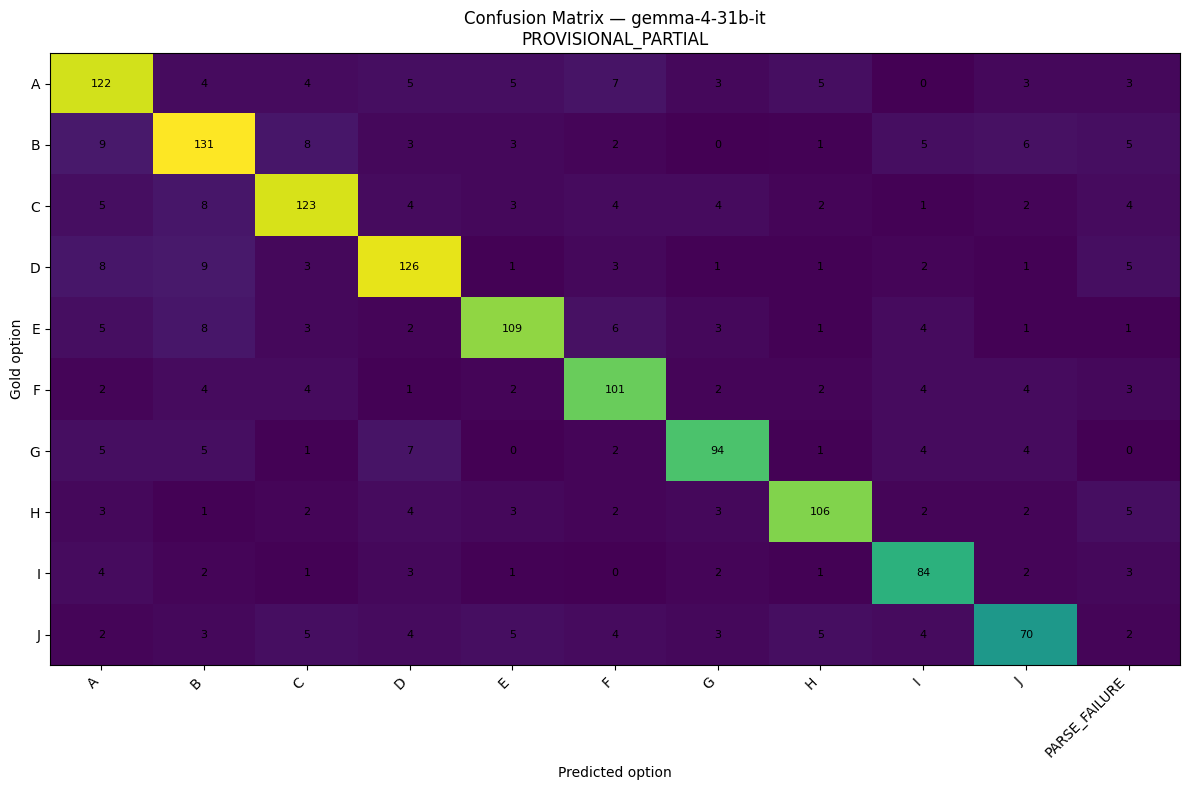

In [23]:
if n_valid:
    max_choices_observed = int(results['n_options'].max())
    observed_choice_labels = choice_letters(max_choices_observed)
    labels = observed_choice_labels + ['PARSE_FAILURE']

    cm = confusion_matrix(yt, yp, labels=labels)

    # Gold labels occupy only rows actually present in the dataset.
    gold_labels_present = [
        label for label in observed_choice_labels
        if label in set(yt)
    ]
    row_indices = [labels.index(label) for label in gold_labels_present]
    cm_display = cm[row_indices, :]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(cm_display, aspect='auto')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(gold_labels_present)))
    ax.set_yticklabels(gold_labels_present)

    ax.set_xlabel('Predicted option')
    ax.set_ylabel('Gold option')
    ax.set_title(f'Confusion Matrix — {MODEL}\n{status}')

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, str(cm_display[i, j]),
                ha='center', va='center', fontsize=8
            )

    fig.tight_layout()
    fig.savefig(
        PLOTS_DIR / 'confusion_matrix.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()

# 19. Runtime, throughput, token cost, output-length and retry metrics

In [24]:
def num(s): return pd.to_numeric(s,errors='coerce')
sessions=read_jsonl(SESSIONS); events=read_jsonl(EVENTS); active_s=sum(float(x.get('session_active_duration_s') or 0) for x in sessions); eff={}
if n_valid:
    successful_latency=num(results['latency_s']).dropna(); sample_wall=num(results['sample_total_wall_s']).dropna(); pt=num(results['prompt_tokens']).dropna(); ct=num(results['completion_tokens']).dropna(); rt=num(results['reasoning_tokens']).dropna(); tt=num(results['total_tokens']).dropna()
    total_pt=float(pt.sum()) if len(pt) else np.nan; total_ct=float(ct.sum()) if len(ct) else np.nan; total_rt=float(rt.sum()) if len(rt) else np.nan; total_tt=float(tt.sum()) if len(tt) else np.nan
    attempt_elapsed=[float(e['elapsed_s']) for e in events if e.get('elapsed_s') is not None and e.get('event')!='retry_backoff']; backoffs=[float(e['backoff_s']) for e in events if e.get('event')=='retry_backoff' and e.get('backoff_s') is not None]; total_success=float(successful_latency.sum())
    eff={'total_active_kaggle_session_s':active_s,'total_active_kaggle_session_h':active_s/3600,'calls_per_min_active_session':60*n_valid/active_s if active_s else np.nan,
      'total_successful_api_latency_s':total_success,'mean_successful_api_latency_s':float(successful_latency.mean()),'median_successful_api_latency_s':float(successful_latency.median()),'p95_successful_api_latency_s':float(successful_latency.quantile(.95)),
      'total_sample_wall_s':float(sample_wall.sum()),'mean_sample_wall_s':float(sample_wall.mean()),'median_sample_wall_s':float(sample_wall.median()),'p95_sample_wall_s':float(sample_wall.quantile(.95)),
      'total_logged_api_attempt_elapsed_s':float(sum(attempt_elapsed)),'total_logged_retry_backoff_s':float(sum(backoffs)),'logged_retry_backoff_events':len(backoffs),
      'total_prompt_tokens':total_pt,'mean_prompt_tokens':float(pt.mean()) if len(pt) else np.nan,'total_completion_tokens':total_ct,'mean_completion_tokens':float(ct.mean()) if len(ct) else np.nan,
      'total_provider_reasoning_tokens_if_exposed':total_rt,'mean_provider_reasoning_tokens_if_exposed':float(rt.mean()) if len(rt) else np.nan,'total_tokens':total_tt,'mean_total_tokens':float(tt.mean()) if len(tt) else np.nan,
      'completion_tokens_per_successful_api_second':total_ct/total_success if total_success>0 and not math.isnan(total_ct) else np.nan,'total_visible_output_chars':int(results['visible_output_chars'].sum()),'mean_visible_output_chars':float(results['visible_output_chars'].mean()),
      'total_visible_output_words':int(results['visible_output_words'].sum()),'mean_visible_output_words':float(results['visible_output_words'].mean()),'total_provider_reasoning_chars_if_exposed':int(results['reasoning_chars'].sum()),
      'mean_provider_reasoning_chars_if_exposed':float(results['reasoning_chars'].mean()),'total_combined_output_chars':int(results['combined_output_chars'].sum()),'mean_combined_output_chars':float(results['combined_output_chars'].mean()),
      'responses_with_more_than_one_attempt_in_successful_pass':int((results['attempts']>1).sum()),'logged_retry_events':sum(1 for e in events if e.get('will_retry') is True and e.get('event')!='retry_backoff'),
      'logged_pass_exhaustions':sum(1 for e in events if e.get('event')=='pass_exhausted_without_valid_response'),'logged_http_429_events':sum(1 for e in events if e.get('http_status')==429),
      'strict_format_failures':int((results['strict_prediction']=='PARSE_FAILURE').sum()),'truncated_responses':int(results['truncated'].astype(bool).sum())}
    if PRICE_INPUT_PER_1M_USD is not None and PRICE_OUTPUT_PER_1M_USD is not None: eff['estimated_monetary_api_cost_usd']=total_pt/1e6*PRICE_INPUT_PER_1M_USD+total_ct/1e6*PRICE_OUTPUT_PER_1M_USD
    else: eff['estimated_monetary_api_cost_usd']=None
    display(pd.DataFrame([eff]).T.rename(columns={0:'value'}).round(4))

,value
total_active_kaggle_session_s,151464.379844
total_active_kaggle_session_h,42.073439
calls_per_min_active_session,0.551417
total_successful_api_latency_s,140524.724864
mean_successful_api_latency_s,100.95167
median_successful_api_latency_s,60.842835
p95_successful_api_latency_s,322.571355
total_sample_wall_s,142288.847275
mean_sample_wall_s,102.218999
median_sample_wall_s,61.117652


# 20. Latency and completion-token distributions

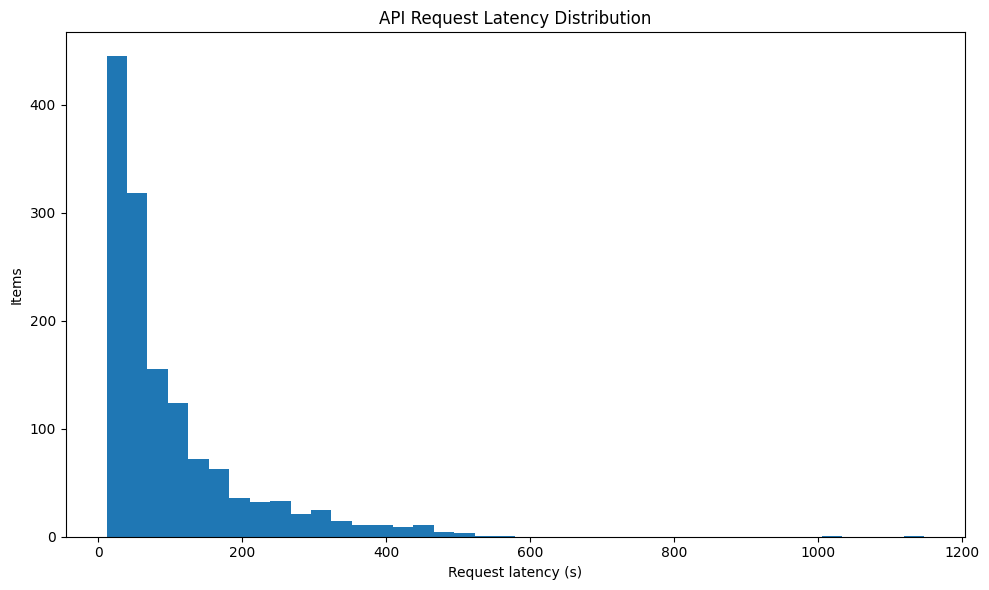

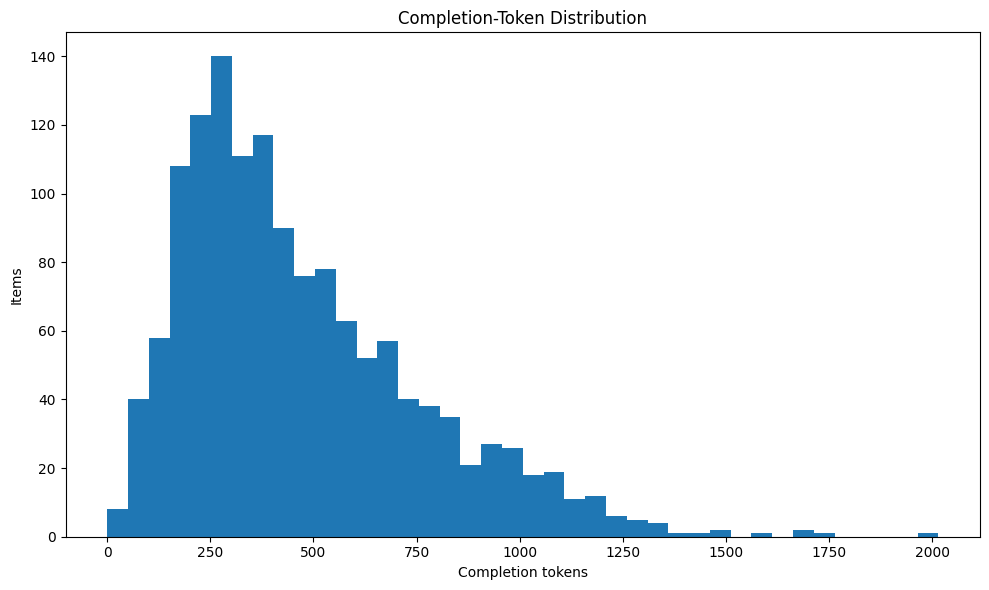

In [25]:
if n_valid:
    fig,ax=plt.subplots(figsize=(10,6)); ax.hist(num(results['latency_s']).dropna(),bins=40); ax.set_xlabel('Request latency (s)'); ax.set_ylabel('Items'); ax.set_title('API Request Latency Distribution'); fig.tight_layout(); fig.savefig(PLOTS_DIR/'latency_distribution.png',dpi=180,bbox_inches='tight'); plt.show()
if n_valid and results['completion_tokens'].notna().any():
    fig,ax=plt.subplots(figsize=(10,6)); ax.hist(num(results['completion_tokens']).dropna(),bins=40); ax.set_xlabel('Completion tokens'); ax.set_ylabel('Items'); ax.set_title('Completion-Token Distribution'); fig.tight_layout(); fig.savefig(PLOTS_DIR/'completion_tokens.png',dpi=180,bbox_inches='tight'); plt.show()

# 21. Subject, domain, difficulty, image-type and image-count analyses

In [26]:
DOMAIN={'Art and Design':['Art','Art_Theory','Design','Music'],'Business':['Accounting','Economics','Finance','Manage','Marketing'],
 'Science':['Biology','Chemistry','Geography','Math','Physics'],'Health and Medicine':['Basic_Medical_Science','Clinical_Medicine','Diagnostics_and_Laboratory_Medicine','Pharmacy','Public_Health'],
 'Humanities and Social Science':['History','Literature','Sociology','Psychology'],'Tech and Engineering':['Agriculture','Architecture_and_Engineering','Computer_Science','Electronics','Energy_and_Power','Materials','Mechanical_Engineering']}
S2D={s:d for d,ss in DOMAIN.items() for s in ss}
def group_acc(df,col): return df.groupby(col,dropna=False).agg(n=('sample_id','size'),correct=('strict_correct','sum'),accuracy=('strict_correct','mean'),mean_latency_s=('latency_s','mean'),mean_completion_tokens=('completion_tokens','mean')).reset_index()
if n_valid:
    results['domain']=results['subject'].map(S2D).fillna('Other/Unmapped')
    subject=group_acc(results,'subject'); domain=group_acc(results,'domain'); diff=group_acc(results,'topic_difficulty'); imgt=group_acc(results,'img_type'); imgc=group_acc(results,'image_count')
    subject.to_csv(SUBJECT_CSV,index=False); domain.to_csv(DOMAIN_CSV,index=False); diff.to_csv(DIFF_CSV,index=False); imgt.to_csv(IMGTYPE_CSV,index=False); imgc.to_csv(IMGCOUNT_CSV,index=False)
    print('Domain'); display(domain.round(4)); print('Difficulty'); display(diff.round(4)); print('Image count'); display(imgc.round(4)); print('Subject'); display(subject.round(4))

Domain


,domain,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Art and Design,184,125,0.6793,81.4860,247.0217
1,Business,234,207,0.8846,93.0761,547.4316
2,Health and Medicine,226,161,0.7124,70.3905,371.7876
3,Humanities and Social Science,185,135,0.7297,60.1969,291.6000
4,Science,226,185,0.8186,98.2709,492.7611
5,Tech and Engineering,337,253,0.7507,161.7139,696.5994


Difficulty


,topic_difficulty,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Easy,435,355,0.8161,72.4933,357.1218
1,Hard,333,234,0.7027,137.6335,610.5676
2,Medium,624,477,0.7644,101.2150,479.1218


Image count


,image_count,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,1,1279,985,0.7701,99.4944,471.7201
1,2,57,44,0.7719,114.9409,497.5965
2,3,11,9,0.8182,112.4091,466.9091
3,4,29,18,0.6207,107.3356,420.5862
4,5,15,9,0.6000,151.5851,543.8667
5,7,1,1,1.0000,96.7253,455.0000


Subject


,subject,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Accounting,43,40,0.9302,81.8659,532.1395
1,Agriculture,49,27,0.5510,54.0087,224.4898
2,Architecture_and_Engineering,52,39,0.7500,214.0311,930.8269
3,Art,46,33,0.7174,35.6356,187.0000
4,Art_Theory,43,36,0.8372,52.5373,204.4884
5,Basic_Medical_Science,45,33,0.7333,47.9451,290.8889
6,Biology,45,36,0.8000,85.9868,386.8889
7,Chemistry,46,38,0.8261,118.9608,520.9783
8,Clinical_Medicine,46,28,0.6087,61.2366,320.4130
9,Computer_Science,49,37,0.7551,118.3547,547.9592


# 22. Answer-position bias diagnostics

,letter,gold_count,predicted_count
0,A,161,165
1,B,173,175
2,C,160,154
3,D,160,159
4,E,143,132
5,F,129,131
6,G,123,115
7,H,133,125
8,I,103,110
9,J,107,95


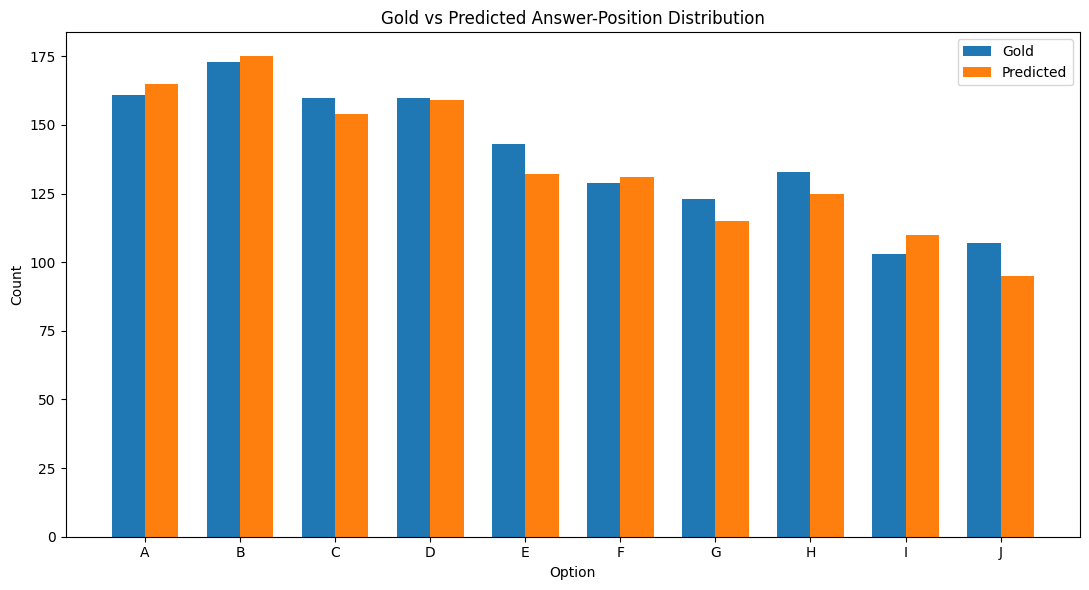

In [27]:
if n_valid:
    position_labels = choice_letters(int(results['n_options'].max()))

    g = results['gold_answer'].value_counts().reindex(position_labels, fill_value=0)
    p = results['strict_prediction'].value_counts().reindex(position_labels, fill_value=0)

    pos = pd.DataFrame({
        'letter': position_labels,
        'gold_count': g.values,
        'predicted_count': p.values,
    })
    display(pos)

    x = np.arange(len(position_labels))
    w = .35
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - w/2, pos['gold_count'], w, label='Gold')
    ax.bar(x + w/2, pos['predicted_count'], w, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(position_labels)
    ax.set_xlabel('Option')
    ax.set_ylabel('Count')
    ax.set_title('Gold vs Predicted Answer-Position Distribution')
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR/'answer_positions.png', dpi=180, bbox_inches='tight')
    plt.show()

# 23. Consolidated paper-ready summary

In [28]:
summary={'analysis_status':status,'experiment_id':EXPERIMENT_ID,'model':MODEL,'provider':PROVIDER,'api_method':API_METHOD,'dataset_revision':DATASET_REVISION,'n_dataset':n_total,'n_valid':n_valid,'coverage':coverage,
 'prompt_id':PROMPT_ID,'prompt_family':PROMPT_FAMILY,'prompt_suffix_sha256':PROMPT_SHA,'classification':classification,'efficiency':eff,'strict_format_compliance':None if pd.isna(fmt) else float(fmt),'truncation_rate':None if pd.isna(trunc) else float(trunc)}
SUMMARY_JSON.write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8'); flat_summary={'analysis_status':status,'model':MODEL,'provider':PROVIDER,'api_method':API_METHOD,'dataset_revision':DATASET_REVISION,'n_dataset':n_total,'n_valid':n_valid,'coverage':coverage,**classification,**eff}
pd.DataFrame([flat_summary]).to_csv(SUMMARY_CSV,index=False); display(pd.DataFrame([flat_summary]).T.rename(columns={0:'value'}))

,value
analysis_status,PROVISIONAL_PARTIAL
model,gemma-4-31b-it
provider,Google Gemini Developer API
api_method,interactions.create
dataset_revision,563f3e84bb3b90893083a1f039cfa13077f2302b
...,...
logged_pass_exhaustions,2
logged_http_429_events,0
strict_format_failures,31
truncated_responses,10


# 24. Professional qualitative audit viewer

In [29]:
def br(x): return html.escape(str(x or '')).replace('\n','<br>')
if GENERATE_HTML_AUDIT and n_valid:
    cards=[]
    for _,r in results.sort_values('execution_order').iterrows():
        imgs=''.join(f'<img src="{html.escape(p)}" style="max-width:420px;max-height:320px;margin:6px;border:1px solid #ddd">' for p in str(r['image_files']).split(';') if p)
        opts=json.loads(r['options_json']); ol='<ol type="A">'+''.join(f'<li>{html.escape(str(o))}</li>' for o in opts)+'</ol>'
        verdict='CORRECT' if bool(r['strict_correct']) else 'WRONG'
        cards.append(f"""<section style="border:1px solid #bbb;padding:16px;margin:18px 0"><h2>{html.escape(str(r['sample_id']))} — {verdict}</h2>
        <p><b>Subject:</b> {html.escape(str(r['subject']))}<br><b>Strict prediction:</b> {html.escape(str(r['strict_prediction']))}<br><b>Gold:</b> {html.escape(str(r['gold_answer']))} — {html.escape(str(r['gold_option_text']))}</p>
        <div>{imgs}</div><h3>Question</h3><p>{br(r['question'])}</p><h3>Options</h3>{ol}<h3>Visible model response</h3><div style="background:#f6f6f6;padding:10px">{br(r['visible_response'])}</div>
        <h3>Model-provided reasoning field</h3><div style="background:#fafafa;padding:10px">{br(r['reasoning_content'])}</div><h3>Gold explanation — reference only; never sent to model</h3><div style="background:#fff9e8;padding:10px">{br(r['gold_explanation'])}</div></section>""")
    doc=f'<!doctype html><html><head><meta charset="utf-8"><title>{EXPERIMENT_ID}</title></head><body style="font-family:Arial;max-width:1200px;margin:auto;padding:20px"><h1>{EXPERIMENT_ID}</h1><p><b>Status:</b> {status}; {n_valid}/{n_total}</p>'+''.join(cards)+'</body></html>'
    AUDIT_HTML.write_text(doc,encoding='utf-8'); print('Saved',AUDIT_HTML)

Saved /kaggle/working/gemma4_31b_p0_mmmupro_s10_interactions/audit_viewer.html


# 25. README_RESULTS.md and final completion gate

In [30]:
def pct(x):
    return "N/A" if x is None or pd.isna(x) else f"{100*float(x):.2f}%"

readme = f"""# {EXPERIMENT_ID}

## Status
**{status}** — {n_valid}/{n_total} valid model responses.

## Dataset
- `{DATASET_REPO}` / `{DATASET_CONFIG}` / `{DATASET_SPLIT}`
- Frozen revision: `{DATASET_REVISION}`
- Order seed: `{ORDER_SEED}`
- Order SHA256: `{ORDER_SHA}`
- Paired expected order SHA256: `{EXPECTED_ORDER_SHA}`

## Model / API
- Model: `{MODEL}`
- Provider: `{PROVIDER}`
- API method: `{API_METHOD}`
- API mode: `{API_MODE}`
- SDK: `{SDK_PIN}`
- Temperature requested: `{TEMPERATURE}`
- Top-p requested: `{TOP_P}`
- Max output tokens: `{MAX_TOKENS}`
- Fixed API seed: `{API_SEED}`
- Protocol version: `{PROTOCOL_VERSION}`

## Request policy
- Images: lossless PNG, image_1..image_7, then text
- Gold answer sent: no
- Gold explanation sent: no
- Few-shot demonstrations: no
- Returned completed/incomplete interactions are never content-retried

## Scheduling
- Client timeout: `{REQUEST_TIMEOUT_S}` s
- HttpOptions timeout: `{REQUEST_TIMEOUT_MS}` ms
- SDK internal attempts: `{SDK_INTERNAL_RETRY_ATTEMPTS}`
- Application attempts per pass: `{MAX_ATTEMPTS}`
- Deferred retry passes: `{DEFERRED_RETRY_PASSES}`
- Inter-request delay: `{INTER_REQUEST_DELAY_S}` s
- Consecutive exhausted-429 stop: `{MAX_CONSECUTIVE_EXHAUSTED_429}`
- Soft stop: `{SOFT_WALLCLOCK_HOURS}` h

## P0 prompt suffix
```text
{PROMPT_SUFFIX}
```

Prompt SHA256: `{PROMPT_SHA}`

## Headline results
- Strict accuracy: {pct(classification.get('strict_accuracy'))}
- Macro F1: {classification.get('macro_f1','N/A')}
- Weighted F1: {classification.get('weighted_f1','N/A')}
- Strict format compliance: {pct(fmt)}
- Incomplete/truncation rate: {pct(trunc)}

## Canonical artifacts
- `raw_results.jsonl`
- `api_events.jsonl`
- `run_sessions.jsonl`
- `api_preflight.json`
- `dataset_integrity_audit.json`
- `dataset_manifest.jsonl`
- `google_model_info.json`
- `results_all.csv`
- `summary_metrics.json`
- `class_metrics_all_choice_letters.csv`
- `accuracy_by_subject.csv`
- `audit_viewer.html`
- `media/`

Only `FINAL_FULL_DATASET` results should be reported as final paper results.
"""

README.write_text(readme, encoding="utf-8")
print(readme)

top_level_files = sorted(p for p in WORKDIR.iterdir() if p.is_file())
media_files = list(MEDIA_DIR.glob("*")) if MEDIA_DIR.exists() else []
media_bytes = sum(p.stat().st_size for p in media_files if p.is_file())

print("\nTop-level artifact inventory:")
for p in top_level_files:
    print("-", p.name, f"({p.stat().st_size/1024:.1f} KB)")

print(
    f"- media/: {len(media_files)} files, "
    f"{media_bytes/(1024**2):.2f} MiB total"
)

print("\n" + "=" * 80)
if complete:
    print("FULL DATASET COMPLETE — 1730/1730. Metrics are FINAL_FULL_DATASET.")
else:
    print(
        f"PARTIAL CHECKPOINT — {n_valid}/{n_total}. "
        "Save Version, attach its output as Input, and rerun."
    )
print("=" * 80)

# MMMUPro-S10__Gemma4-31B-IT__P0-ExplanationBaseline__Interactions__FINAL__FixedSeed20260829

## Status
**PROVISIONAL_PARTIAL** — 1392/1730 valid model responses.

## Dataset
- `MMMU/MMMU_Pro` / `standard (10 options)` / `test`
- Frozen revision: `563f3e84bb3b90893083a1f039cfa13077f2302b`
- Order seed: `20260829`
- Order SHA256: `c3aeed34268eccb9670210f3c97a0fc55018ed0c1d2695d9dc2e7d0c16ffd3a1`
- Paired expected order SHA256: `c3aeed34268eccb9670210f3c97a0fc55018ed0c1d2695d9dc2e7d0c16ffd3a1`

## Model / API
- Model: `gemma-4-31b-it`
- Provider: `Google Gemini Developer API`
- API method: `interactions.create`
- API mode: `stateless`
- SDK: `google-genai==2.20.0`
- Temperature requested: `1.0`
- Top-p requested: `0.95`
- Max output tokens: `16384`
- Fixed API seed: `20260829`
- Protocol version: `P0_GEMMA4_31B_INTERACTIONS_FINAL_V2_20260829`

## Request policy
- Images: lossless PNG, image_1..image_7, then text
- Gold answer sent: no
- Gold explanation sent: no
- Few-shot demonstrations

# 27. Suggested Methods wording for the thesis/paper

> **Gemma 4 31B baseline evaluation.** We evaluated `gemma-4-31b-it` on
> the complete official MMMU-Pro `standard (10 options)` test setting
> (1,730 rows) at the frozen Hugging Face revision
> `563f3e84bb3b90893083a1f039cfa13077f2302b`. Candidate options were
> preserved exactly as serialized in each official row, without filtering,
> padding, truncation, or fabrication, and answer letters were assigned
> dynamically in option order. The execution order was deterministically
> shuffled using seed `20260829` and verified against the paired reference
> order using SHA-256.
>
> All associated non-null images were supplied in dataset-column order
> (`image_1` through `image_7`) before the textual question and candidate list.
> Images were sent losslessly as PNG and the exact transmitted bytes were
> archived and SHA-256 hashed. No demonstrations or few-shot examples were
> provided. Gold answers and dataset-provided reference explanations were
> retained only for evaluation and were never included in model input.
>
> P0 instructed the model to provide a visible explanation and terminate with
> `Answer: $LETTER`. The hosted evaluation used the Google Gemini Developer
> Interactions API in stateless mode (`store=False`) with
> `google-genai==2.20.0`, the SDK version previously validated by a successful
> multimodal Gemma 4 31B pilot. The experiment requested
> `temperature=1.0`, `top_p=0.95`, `max_output_tokens=16384`, and a single
> fixed decoding seed (`20260829`) for every benchmark item. The exact request
> configuration was archived, and a mandatory exact-request preflight blocked
> the full run if the provider rejected the frozen schema or parameters.
> Hosted seeded inference was treated as best-effort reproducibility.
>
> A returned interaction with status `completed` or `incomplete` was retained
> exactly once regardless of answer correctness, formatting, emptiness, or
> truncation. Retries were restricted to infrastructure/API failures. SDK-level
> retries were disabled so each application attempt was observable. Each failed
> item received at most two attempts per pass; unresolved items were deferred,
> followed by one deferred retry pass. Repeated quota failures triggered an
> orderly checkpoint stop rather than converting provider failures into wrong
> model answers.
>
> The run archived raw API responses, visible generated rationale,
> provider-exposed thought summaries when present, token usage, successful
> request latency, end-to-end sample wall time, retry/backoff events, complete
> prompts, image hashes, dataset provenance, execution-order provenance, model
> metadata, environment metadata, and preflight diagnostics. Primary scoring
> used a strict row-aware final-answer parser; malformed final-answer formatting
> counted as incorrect. Accuracy was the primary outcome, with Wilson and
> bootstrap confidence intervals and multiclass, formatting, runtime, token,
> answer-position, and subgroup diagnostics as secondary analyses.